# Does the gateway-field retention signal replicate? — evaluation demo

**Artifact:** `art_lwI2DuRtQRZX` (evaluation, iteration 2), script `eval.py`. **Pre-registered verdict: FAILS.**

In iteration 1, experiment *exp4* found one live lead. An adopting field's **gateway centrality** (`gateway_j`) seemed
to predict **field retention** `R`: whether a field that took up a new concept still publishes on it 6-8 years later.
`gateway_j` is the eigenvector centrality of that field on a 26-field PMI relatedness backbone built from 1998-2002
papers. It added **+0.103 AUC** over the field baseline, but only on 80 episodes (28 concepts).

`eval.py` stress-tests that lead without calling any API. It reads the iteration-1 files and runs these blocks:

| block | question |
|---|---|
| Step 0 | Harmonise the files and reproduce exp4's +0.10254 / +0.10222 exactly |
| A | Leave-one-group-out (LOGO) logistic delta-AUC of `gateway_j` over baselines M0/M1/M2, with a concept-clustered **refit** bootstrap |
| B | Trait confound: leave-concept-out field propensity `P` (B1), field-intercept decomposition (B2), time-varying backbone (B3) |
| C | Placebos: degree-preserving rewiring (C1), node-label permutation (C2), rival centralities with Holm correction (C3) |
| D | Are the concept-level O1 gains of the 8 G-variants label-coverage artefacts? |
| E / F | Power / MDE simulation, and corrected record tables (F5 = refit CIs for exp4's field-level rows) |

**What this notebook runs.** It runs the original code on the **exp4 panel**: 80 episodes, the 46-concept feature
table, the 26-field backbone, and the pooled rows used for `P_pooled`. That covers Step 0, A, B1, B2, C1-C3, D and F5.
Blocks B3 and E, and the union and new-episodes panels behind the final verdict, need the full exp1/exp3 files and
exp3's topic-pair scan checkpoint. For those, the last cells show the reference numbers from the full run
(`reference_full_run` in the data file).

Bootstrap, permutation and rewiring counts are **scaled down** so the notebook finishes in a few minutes. The original
values are listed in the config cell.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0',
         'networkx==3.6.1', 'statsmodels==0.14.6')

## Imports

This is the original `eval.py` import block. The only change is the logger: it writes to stdout only, with no
`logs/eval.log` file. The iteration-1 modules (`harmonise`, `lib`, exp4's `screen`) are rebuilt in the cells below.

In [2]:
import argparse
import json
import math
import multiprocessing as mp
import pickle
import resource
import sys
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import norm, spearmanr


import os
import types
import matplotlib.pyplot as plt
from IPython.display import Image, display

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_zHNZ2UaQoGXD/round-2/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if k != "description"})

exp4 panel of the gateway-field retention stress test: 80 adoption episodes (concept x off-home field) with retention R, the 46-concept feature table, the 26-field 1998-2002 PMI backbone and the pooled field-retention rows of all three iteration-1 files (for the pooled propensity P_pooled).
{'field_outcomes': 80, 'features': 46, 'outcomes_O1': 78, 'field_backbone': 7, 'pool': 576, 'screen_result_exp4': 3, 'prereg_verdict_ladder': 7, 'reference_full_run': 2}


## Configuration

`eval.py` read these values from `argparse`. Here they sit in an `args` namespace, so the original `args.n_boot`-style
references work unchanged. The values are scaled down for a short demo; the original defaults are in the comments.
`N_BOOT_COEF` and `N_PERM_WLS` were literals inside `main()` (1000 draws for the standardised-coefficient bootstrap on
exp4, 2000 permutations for the stage-2 WLS test).

In [5]:
args = types.SimpleNamespace(
    n_boot=400,             # original 2000 (union / new-episodes panels; not run here)
    n_boot_secondary=400,   # original 2000 (exp1 / exp3 panels; not run here)
    n_boot_exp4=400,        # original 2000 - refit bootstrap draws for exp4 (Block A)
    n_boot_D=300,           # original 1000 - Block D concept bootstrap
    n_boot_F5=300,          # original 1000 - F5 refit CIs
    n_perm=1000,            # original 1000 - C2 node-label permutations
    n_rewire=200,           # original 200  - C1 degree-preserving rewirings
    n_sim=500,             # original 500  - Block E (not run in this demo)
    use_cache=False,
    blocks="ABCDF",        # original "ABCDEF"
)
N_BOOT_COEF = 1000       # original 1000 (exp4) / 300 (other panels)
N_PERM_WLS = 2000        # original 2000
N_WORKERS = 2          # original 4 (Colab has 2 vCPUs)
SEED = 20260928

## exp4's `screen.py`, the model under test

`eval.py` imports iteration-1 exp4's own `screen.py` read-only, so the LOGO model is exactly the one that produced the
+0.103. The cell writes that file to disk unchanged. It has to be a real module because the spawn process-pool workers
must be able to import it.

- `logo_predict`: leave-one-home-group-out predictions over the groups CS / Eng / BGM / Med, using standardised L2
  logistic regression with training-fold median imputation.
- `field_level`: exp4's original field-level delta-AUC. Its CI is a fixed-prediction bootstrap, which this evaluation
  replaces.

In [6]:
%%writefile screen.py
"""Pre-registered S0 screen statistics: LOGO ridge/logistic, paired bootstrap deltas, per-group signs,
DerSimonian-Laird pooling, field-level clustered bootstrap."""
from __future__ import annotations

import math
import warnings

import numpy as np
import pandas as pd
from scipy.stats import norm, rankdata, spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
GROUPS = ["CS", "Eng", "BGM", "Med"]


def _prep(X: pd.DataFrame, train: np.ndarray) -> np.ndarray:
    """Median-impute each column with the TRAINING-fold median (G's missing indicator is a separate column)."""
    X = X.copy()
    for c in X.columns:
        med = X.loc[train, c].median()
        X[c] = X[c].fillna(med if np.isfinite(med) else 0.0)
    return X.values.astype(float)


def logo_predict(df: pd.DataFrame, cols: list[str], y: str, kind: str = "ridge") -> np.ndarray:
    """Leave-one-home-group-out out-of-fold predictions."""
    oof = np.full(len(df), np.nan)
    g = df["group"].values
    for lg in GROUPS:
        te = g == lg
        tr = ~te
        if te.sum() == 0 or tr.sum() < 5:
            continue
        Xall = _prep(df[cols], tr)
        yt = df.loc[tr, y].values
        if kind == "ridge":
            m = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            m.fit(Xall[tr], yt)
            oof[te] = m.predict(Xall[te])
        else:
            if len(np.unique(yt)) < 2:
                oof[te] = yt.mean()
                continue
            m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
            m.fit(Xall[tr], yt.astype(int))
            oof[te] = m.predict_proba(Xall[te])[:, 1]
    return oof


def _sp(a, b) -> float:
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 4 or np.std(a[ok]) == 0 or np.std(b[ok]) == 0:
        return math.nan
    return float(spearmanr(a[ok], b[ok]).statistic)


def _auc(y, p) -> float:
    ok = np.isfinite(p) & np.isfinite(y)
    if ok.sum() < 4 or len(np.unique(y[ok])) < 2:
        return math.nan
    return float(roc_auc_score(y[ok].astype(int), p[ok]))


def paired_delta(df: pd.DataFrame, base: list[str], cand: list[str], y: str, kind: str = "ridge",
                 n_boot: int = 2000, seed: int = 20260928, refit_boot: int = 0) -> dict:
    d = df[np.isfinite(df[y].values.astype(float))].reset_index(drop=True)
    ob = logo_predict(d, base, y, kind)
    oc = logo_predict(d, cand, y, kind)
    Y = d[y].values.astype(float)
    stat = _sp if kind == "ridge" else (lambda p, yy: _auc(yy, p))
    sb, sc = stat(ob, Y), stat(oc, Y)
    rng = np.random.default_rng(seed)
    n = len(d)
    boots = []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        a, b = stat(ob[i], Y[i]), stat(oc[i], Y[i])
        if np.isfinite(a) and np.isfinite(b):
            boots.append(b - a)
    boots = np.array(boots)
    per = {}
    for g in GROUPS:
        m = d["group"].values == g
        pb, pc = stat(ob[m], Y[m]), stat(oc[m], Y[m])
        per[g] = {"n": int(m.sum()), "base": pb, "cand": pc,
                  "delta": (pc - pb) if np.isfinite(pb) and np.isfinite(pc) else math.nan}
    out = {"n": n, "metric": "spearman" if kind == "ridge" else "auc", "base": sb, "cand": sc, "delta": sc - sb,
           "ci90": [float(np.percentile(boots, 5)), float(np.percentile(boots, 95))] if len(boots) else [math.nan] * 2,
           "ci95": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))] if len(boots) else [math.nan] * 2,
           "p_boot_le0": float(np.mean(boots <= 0)) if len(boots) else math.nan,
           "per_group": per,
           "n_groups_positive": int(sum(1 for v in per.values() if np.isfinite(v["delta"]) and v["delta"] > 0)),
           "n_groups_evaluable": int(sum(1 for v in per.values() if np.isfinite(v["delta"]))),
           "oof_base": ob.tolist(), "oof_cand": oc.tolist(), "concepts": d["concept"].tolist()}
    if refit_boot:
        rr = []
        for _ in range(refit_boot):
            idx = np.concatenate([rng.choice(np.where(d["group"].values == g)[0], (d["group"].values == g).sum())
                                  for g in GROUPS if (d["group"].values == g).sum()])
            dd = d.iloc[idx].reset_index(drop=True)
            a = stat(logo_predict(dd, base, y, kind), dd[y].values.astype(float))
            b = stat(logo_predict(dd, cand, y, kind), dd[y].values.astype(float))
            if np.isfinite(a) and np.isfinite(b):
                rr.append(b - a)
        rr = np.array(rr)
        out["refit_boot"] = {"n": int(len(rr)), "ci90": [float(np.percentile(rr, 5)), float(np.percentile(rr, 95))]
                             if len(rr) else [math.nan] * 2, "mean": float(rr.mean()) if len(rr) else math.nan}
    return out


def loco_delta(df: pd.DataFrame, base: list[str], cand: list[str], y: str) -> dict:
    """Supplementary leave-one-concept-out ridge Delta-rho."""
    d = df[np.isfinite(df[y].values.astype(float))].reset_index(drop=True)
    res = {}
    for nm, cols in (("base", base), ("cand", cand)):
        oof = np.full(len(d), np.nan)
        for i in range(len(d)):
            tr = np.ones(len(d), bool)
            tr[i] = False
            X = _prep(d[cols], tr)
            m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X[tr], d.loc[tr, y].values)
            oof[i] = m.predict(X[~tr])[0]
        res[nm] = _sp(oof, d[y].values.astype(float))
    return {"base": res["base"], "cand": res["cand"], "delta": res["cand"] - res["base"], "n": len(d)}


# ------------------------------------------------------------------ meta-analysis
def dersimonian_laird(est: list[float], var: list[float]) -> dict:
    e = np.array(est, float)
    v = np.array(var, float)
    ok = np.isfinite(e) & np.isfinite(v) & (v > 0)
    e, v = e[ok], v[ok]
    k = len(e)
    if k < 2:
        return {"k": k, "pooled": float(e[0]) if k else math.nan, "se": math.nan, "tau2": math.nan, "I2": math.nan}
    w = 1 / v
    fe = (w * e).sum() / w.sum()
    Q = (w * (e - fe) ** 2).sum()
    C = w.sum() - (w ** 2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0
    ws = 1 / (v + tau2)
    re = (ws * e).sum() / ws.sum()
    se = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 else 0.0
    return {"k": k, "pooled": float(re), "se": float(se), "tau2": float(tau2), "I2": float(I2), "Q": float(Q)}


def hanley_mcneil_var(auc: float, n1: int, n0: int) -> float:
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return (auc * (1 - auc) + (n1 - 1) * (q1 - auc ** 2) + (n0 - 1) * (q2 - auc ** 2)) / (n1 * n0)


def single_indicator(df: pd.DataFrame, feat: str, y: str, binary: bool) -> dict:
    d = df[np.isfinite(df[y].values.astype(float)) & np.isfinite(df[feat].values.astype(float))]
    x, Y = d[feat].values.astype(float), d[y].values.astype(float)
    res = {"feature": feat, "outcome": y, "n": len(d)}
    if not binary:
        res["pooled"] = _sp(x, Y)
        ests, vars_, per = [], [], {}
        for g in GROUPS:
            m = d["group"].values == g
            r = _sp(x[m], Y[m])
            per[g] = r
            if np.isfinite(r) and m.sum() > 3:
                ests.append(math.atanh(max(min(r, 0.999), -0.999)))
                vars_.append(1.06 / (m.sum() - 3))
        dl = dersimonian_laird(ests, vars_)
        res.update({"per_group": per, "meta_pooled": math.tanh(dl["pooled"]) if np.isfinite(dl["pooled"]) else math.nan,
                    "meta_ci95": [math.tanh(dl["pooled"] - 1.96 * dl["se"]), math.tanh(dl["pooled"] + 1.96 * dl["se"])]
                    if np.isfinite(dl["se"]) else [math.nan] * 2, "I2": dl["I2"], "k": dl["k"],
                    "sign_consistency": int(sum(1 for v in per.values() if np.isfinite(v) and np.sign(v) ==
                                                np.sign(res["pooled"])))})
    else:
        res["pooled_raw"] = _auc(Y, x)
        per_raw, per_or, ests, vars_ = {}, {}, [], []
        for g in GROUPS:
            m = d["group"].values == g
            a = _auc(Y[m], x[m])
            per_raw[g] = a
            atr = _auc(Y[~m], x[~m])  # orientation chosen on training groups only
            sgn = 1 if (not np.isfinite(atr) or atr >= 0.5) else -1
            ao = a if sgn == 1 else (1 - a if np.isfinite(a) else a)
            per_or[g] = ao
            n1, n0 = int(Y[m].sum()), int((1 - Y[m]).sum())
            if np.isfinite(ao) and n1 and n0:
                aa = min(max(ao, 0.01), 0.99)
                ests.append(math.log(aa / (1 - aa)))
                vars_.append(hanley_mcneil_var(aa, n1, n0) / (aa * (1 - aa)) ** 2)
        dl = dersimonian_laird(ests, vars_)
        inv = lambda z: 1 / (1 + math.exp(-z))
        res.update({"per_group_raw": per_raw, "per_group_oriented": per_or,
                    "meta_pooled_oriented": inv(dl["pooled"]) if np.isfinite(dl["pooled"]) else math.nan,
                    "meta_ci95": [inv(dl["pooled"] - 1.96 * dl["se"]), inv(dl["pooled"] + 1.96 * dl["se"])]
                    if np.isfinite(dl["se"]) else [math.nan] * 2, "I2": dl["I2"], "k": dl["k"],
                    "sign_consistency": int(sum(1 for v in per_or.values() if np.isfinite(v) and v > 0.5))})
    return res


# ------------------------------------------------------------------ field level
def field_level(fr: pd.DataFrame, base: list[str], cand: list[str], n_boot: int = 2000, seed: int = 1) -> dict:
    d = fr.dropna(subset=["R"]).reset_index(drop=True)
    ob = logo_predict(d, base, "R", "logit")
    oc = logo_predict(d, cand, "R", "logit")
    Y = d["R"].values.astype(float)
    ab, ac = _auc(Y, ob), _auc(Y, oc)
    rng = np.random.default_rng(seed)
    cons = d["concept"].unique()
    rows = {c: np.where(d["concept"].values == c)[0] for c in cons}
    boots = []
    for _ in range(n_boot):
        pick = rng.choice(cons, len(cons))
        i = np.concatenate([rows[c] for c in pick])
        a, b = _auc(Y[i], ob[i]), _auc(Y[i], oc[i])
        if np.isfinite(a) and np.isfinite(b):
            boots.append(b - a)
    boots = np.array(boots)
    per = {}
    for g in GROUPS:
        m = d["group"].values == g
        per[g] = {"n_rows": int(m.sum()), "base": _auc(Y[m], ob[m]), "cand": _auc(Y[m], oc[m])}
    return {"n_rows": len(d), "n_concepts": len(cons), "prevalence": float(Y.mean()), "auc_base": ab, "auc_cand": ac,
            "delta_auc": ac - ab, "ci90": [float(np.percentile(boots, 5)), float(np.percentile(boots, 95))],
            "ci95": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))], "per_group": per}

Writing screen.py


## `lib.py` (1/4): fast paths

`lib.py` holds the statistics core that the bootstrap workers use. It is written to disk in four parts (`%%writefile -a`
appends). The one change from the original is the import of `screen`: it now comes from the current directory instead
of the iteration-1 folder.

`fast_prep` and `fast_auc` are numpy versions of `screen._prep` and `screen._auc` that give the same numbers. Step 0
checks that on the data before Block A uses them.

In [7]:
%%writefile lib.py
"""Core statistics for the gateway stress test. Worker-safe (imported by spawn workers): no logging side effects.

The LOGO logistic model, training-fold median imputation and AUC come from iteration-1 exp4's screen.py, imported
read-only (never rewritten). The only extension is fold-dependent columns (field propensity P, O1_base) that must be
recomputed inside each training fold to stay leakage-free.
"""
from __future__ import annotations

import math
import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Notebook: exp4's screen.py was written to the current directory by the previous cell.
import screen as S4  # noqa: E402  exp4's own screen.py (logo_predict, _prep, _auc, dersimonian_laird)

GROUPS = S4.GROUPS  # ["CS", "Eng", "BGM", "Med"]
_ORIG_PREP, _ORIG_AUC = S4._prep, S4._auc


def fast_prep(X: pd.DataFrame, train: np.ndarray) -> np.ndarray:
    """Numerically identical numpy version of screen._prep (training-fold median imputation per column)."""
    A = X.to_numpy(dtype=float, copy=True)
    if np.isnan(A).any():
        with np.errstate(all="ignore"):
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                med = np.nanmedian(A[train], axis=0)
        med = np.where(np.isfinite(med), med, 0.0)
        r, c = np.nonzero(np.isnan(A))
        A[r, c] = med[c]
    return A


def fast_auc(y, p) -> float:
    """Rank (Mann-Whitney) AUC with screen._auc's conventions (finite rows, >= 4 rows, both classes)."""
    from scipy.stats import rankdata
    y = np.asarray(y, float)
    p = np.asarray(p, float)
    ok = np.isfinite(p) & np.isfinite(y)
    if ok.sum() < 4:
        return math.nan
    y, p = y[ok], p[ok]
    n1 = y.sum()
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return math.nan
    r = rankdata(p)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


# Speed: exp4's logo_predict looks up _prep at call time; the numpy version gives identical matrices (verified in
# eval.py against the original on every dataset before use).
S4._prep = fast_prep

Writing lib.py


## `lib.py` (2/4): fold-computed propensity and the LOGO evaluator

`propensity` computes **P**, the shrunken leave-concept-out field retention rate:
`P = (sum R + a*pbar) / (n + a)`, with a = 2. It is recomputed inside every LOGO training fold so it never sees
test-fold rows (`P_within`). `P_pooled` uses the rows of all three iteration-1 files instead.

`eval_specs` fits each distinct feature set once and returns the pooled and per-group delta-AUC for every
(base, candidate) pair.

In [8]:
%%writefile -a lib.py
# ----------------------------------------------------------------------------- fold-dependent features
def propensity(key: np.ndarray, cl: np.ndarray, y: np.ndarray, grp: np.ndarray, test_g: str, a: float,
               pool: pd.DataFrame | None = None, concept: np.ndarray | None = None) -> np.ndarray:
    """Shrunken leave-concept-out field retention propensity for one LOGO fold.

    Within-dataset (pool None): statistics from training-fold rows (group != test_g) of the same field key;
    test rows use all training rows of the key, training rows exclude rows of their own cluster (concept copy).
    Pooled: statistics from the external pool (rows of all three files) with group != test_g and concept != own
    concept, for both test and training rows. P = (sum R + a*pbar) / (n + a); pbar = training mean; n=0,a=0 -> pbar.
    """
    n = len(y)
    out = np.empty(n)
    if pool is None:
        tr = grp != test_g
        pbar = float(y[tr].mean())
        d = pd.DataFrame({"k": key[tr], "c": cl[tr], "y": y[tr]})
        tot = d.groupby("k")["y"].agg(["sum", "count"])
        byc = d.groupby(["k", "c"])["y"].agg(["sum", "count"])
        ks = tot.reindex(key)
        s_all = np.nan_to_num(ks["sum"].to_numpy(float))
        n_all = np.nan_to_num(ks["count"].to_numpy(float))
        own = byc.reindex(pd.MultiIndex.from_arrays([key, cl]))
        s_own = np.nan_to_num(own["sum"].to_numpy(float))
        n_own = np.nan_to_num(own["count"].to_numpy(float))
        s = np.where(tr, s_all - s_own, s_all)
        c = np.where(tr, n_all - n_own, n_all)
    else:
        pp = pool[pool["group"].to_numpy() != test_g]
        pbar = float(pp["R"].mean())
        tot = pp.groupby("key")["R"].agg(["sum", "count"])
        byc = pp.groupby(["key", "concept"])["R"].agg(["sum", "count"])
        ks = tot.reindex(key)
        own = byc.reindex(pd.MultiIndex.from_arrays([key, concept]))
        s = np.nan_to_num(ks["sum"].to_numpy(float)) - np.nan_to_num(own["sum"].to_numpy(float))
        c = np.nan_to_num(ks["count"].to_numpy(float)) - np.nan_to_num(own["count"].to_numpy(float))
    den = c + a
    out[:] = np.where(den > 0, (s + a * pbar) / np.where(den > 0, den, 1.0), pbar)
    return out


def logo_ext(df: pd.DataFrame, cols: list[str], y: str = "R", a: float = 2.0, pool: pd.DataFrame | None = None,
             cl_col: str = "cl") -> np.ndarray:
    """exp4 screen.logo_predict(kind='logit') plus fold-computed P columns ('P_within', 'P_pooled')."""
    dyn = [c for c in cols if c in ("P_within", "P_pooled")]
    if not dyn:
        return S4.logo_predict(df, cols, y, "logit")
    oof = np.full(len(df), np.nan)
    g = df["group"].to_numpy()
    Y = df[y].to_numpy(float)
    key = df["key"].to_numpy()
    cl = df[cl_col].to_numpy()
    con = df["concept"].to_numpy()
    for lg in GROUPS:
        te = g == lg
        tr = ~te
        if te.sum() == 0 or tr.sum() < 5:
            continue
        X = df[[c for c in cols if c not in dyn]].copy()
        if "P_within" in dyn:
            X["P_within"] = propensity(key, cl, Y, g, lg, a)
        if "P_pooled" in dyn:
            X["P_pooled"] = propensity(key, cl, Y, g, lg, a, pool=pool, concept=con)
        X = X[cols]
        Xall = S4._prep(X, tr)
        yt = Y[tr]
        if len(np.unique(yt)) < 2:
            oof[te] = yt.mean()
            continue
        m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
        m.fit(Xall[tr], yt.astype(int))
        oof[te] = m.predict_proba(Xall[te])[:, 1]
    return oof


def pooled_auc(y: np.ndarray, p: np.ndarray, g: np.ndarray) -> tuple[float, int]:
    """Pooled OOF AUC after dropping rows of test groups that contain a single class. Returns (auc, n_dropped_groups)."""
    keep = np.ones(len(y), bool)
    nd = 0
    for lg in GROUPS:
        m = g == lg
        if m.sum() and len(np.unique(y[m])) < 2:
            keep &= ~m
            nd += 1
    return fast_auc(y[keep], p[keep]), nd


def group_aucs(y: np.ndarray, p: np.ndarray, g: np.ndarray) -> dict:
    return {lg: fast_auc(y[g == lg], p[g == lg]) for lg in GROUPS}


def eval_specs(df: pd.DataFrame, specs: list[tuple[str, list[str], list[str]]], a: float = 2.0,
               pool: pd.DataFrame | None = None, keep_oof: bool = False) -> dict:
    """Fit every distinct model once; return pooled/per-group delta-AUC per spec."""
    cache: dict[tuple, np.ndarray] = {}
    Y = df["R"].to_numpy(float)
    g = df["group"].to_numpy()

    def get(cols):
        k = tuple(cols)
        if k not in cache:
            cache[k] = logo_ext(df, list(cols), "R", a, pool)
        return cache[k]
    out = {}
    for name, base, cand in specs:
        ob, oc = get(base), get(cand)
        ab, nd = pooled_auc(Y, ob, g)
        ac, _ = pooled_auc(Y, oc, g)
        gb, gc = group_aucs(Y, ob, g), group_aucs(Y, oc, g)
        r = {"auc_base": ab, "auc_cand": ac, "delta": ac - ab, "n_groups_dropped": nd,
             "per_group": {lg: {"base": gb[lg], "cand": gc[lg],
                                "delta": (gc[lg] - gb[lg]) if np.isfinite(gb[lg]) and np.isfinite(gc[lg]) else math.nan}
                           for lg in GROUPS},
             "brier_base": float(np.nanmean((ob - Y) ** 2)), "brier_cand": float(np.nanmean((oc - Y) ** 2))}
        if keep_oof:
            r["oof_base"], r["oof_cand"] = ob, oc
        out[name] = r
    return out

Appending to lib.py


## `lib.py` (3/4): concept-clustered refit bootstrap and placebo workers

In `resample`, every draw resamples whole **concepts**, and each duplicated concept gets a fresh cluster id. Every draw
then **refits** all the LOGO models. This is the "refit bootstrap" behind all new CIs. The iteration-1 CIs resampled
fixed predictions instead. `perm_worker` re-scores placebo gateway vectors: rewired graphs for C1 and permuted node
labels for C2.

In [9]:
%%writefile -a lib.py
def resample(df: pd.DataFrame, rng: np.random.Generator, stratified: bool = False) -> pd.DataFrame:
    """Concept-clustered resample; every duplicated concept gets a fresh cluster id ('cl')."""
    cons = df["concept"].unique()
    rows = {c: np.flatnonzero(df["concept"].to_numpy() == c) for c in cons}
    if stratified:
        cg = df.groupby("concept")["group"].first()
        pick = np.concatenate([rng.choice(cg.index[cg == lg].to_numpy(), (cg == lg).sum())
                               for lg in GROUPS if (cg == lg).sum()])
    else:
        pick = rng.choice(cons, len(cons))
    idx, cid = [], []
    for k, c in enumerate(pick):
        idx.append(rows[c])
        cid.append(np.full(len(rows[c]), k))
    d = df.iloc[np.concatenate(idx)].reset_index(drop=True)
    d["cl"] = np.concatenate(cid)
    return d


def boot_worker(args: tuple) -> list[dict]:
    """One chunk of refit bootstrap draws. args = (df, specs, seeds, a, pool, stratified)."""
    df, specs, seeds, a, pool, stratified = args
    res = []
    for sd in seeds:
        rng = np.random.default_rng(sd)
        d = resample(df, rng, stratified)
        r = eval_specs(d, specs, a, pool)
        res.append({k: {"delta": v["delta"], "nd": v["n_groups_dropped"],
                        "pg": {lg: v["per_group"][lg]["delta"] for lg in GROUPS}} for k, v in r.items()})
    return res


def perm_worker(args: tuple) -> list[dict]:
    """Placebo gateway vectors: args = (df, W, base_cols, gvecs, a). Returns point delta-AUC per vector for each base."""
    df, W, bases, gvecs = args
    Y = df["R"].to_numpy(float)
    g = df["group"].to_numpy()
    base_auc = {nm: pooled_auc(Y, S4.logo_predict(df, cols, "R", "logit"), g)[0] for nm, cols in bases.items()}
    out = []
    for gv in gvecs:
        d = df.copy()
        d["g_plac"] = W @ gv
        r = {}
        for nm, cols in bases.items():
            r[nm] = pooled_auc(Y, S4.logo_predict(d, cols + ["g_plac"], "R", "logit"), g)[0] - base_auc[nm]
        out.append(r)
    return out

Appending to lib.py


## `lib.py` (4/4): concept-level O1 (Block D) and the power simulator (Block E)

`o1_base` / `logo_concept` add a training-fold O1 base rate for Block D. `sim_worker` is Block E's simulator. It is
kept here so `lib.py` stays complete, but this demo does not call it.

In [10]:
%%writefile -a lib.py
# ----------------------------------------------------------------------------- concept-level O1 (Block D)
def o1_base(home: np.ndarray, cl: np.ndarray, y: np.ndarray, grp: np.ndarray, test_g: str) -> np.ndarray:
    """Training-fold mean O1 of concepts sharing the home field (leave-own-concept-out for training rows),
    falling back to the training-fold global mean."""
    tr = grp != test_g
    out = np.empty(len(y))
    gm = y[tr].mean()
    for i in range(len(y)):
        m = tr & (home == home[i]) & (cl != cl[i])
        out[i] = y[m].mean() if m.sum() else (y[tr & (cl != cl[i])].mean() if tr[i] else gm)
    return out


def logo_concept(df: pd.DataFrame, cols: list[str], y: str) -> np.ndarray:
    dyn = "O1_base" in cols
    if not dyn:
        return S4.logo_predict(df, cols, y, "logit")
    oof = np.full(len(df), np.nan)
    g = df["group"].to_numpy()
    Y = df[y].to_numpy(float)
    for lg in GROUPS:
        te = g == lg
        tr = ~te
        if te.sum() == 0 or tr.sum() < 5:
            continue
        X = df[[c for c in cols if c != "O1_base"]].copy()
        X["O1_base"] = o1_base(df["home"].to_numpy(), df["cl"].to_numpy(), Y, g, lg)
        X = X[cols]
        Xa = S4._prep(X, tr)
        yt = Y[tr]
        if len(np.unique(yt)) < 2:
            oof[te] = yt.mean()
            continue
        m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
        m.fit(Xa[tr], yt.astype(int))
        oof[te] = m.predict_proba(Xa[te])[:, 1]
    return oof


def concept_specs_eval(df: pd.DataFrame, specs: list[tuple[str, list[str], list[str]]], y: str = "O1") -> dict:
    cache = {}
    Y = df[y].to_numpy(float)
    g = df["group"].to_numpy()

    def get(cols):
        k = tuple(cols)
        if k not in cache:
            cache[k] = logo_concept(df, list(cols), y)
        return cache[k]
    out = {}
    for nm, b, c in specs:
        ob, oc = get(b), get(c)
        ab, ac = fast_auc(Y, ob), fast_auc(Y, oc)
        pg = {}
        for lg in GROUPS:
            m = g == lg
            x1, x2 = fast_auc(Y[m], ob[m]), fast_auc(Y[m], oc[m])
            pg[lg] = x2 - x1 if np.isfinite(x1) and np.isfinite(x2) else math.nan
        out[nm] = {"base": ab, "cand": ac, "delta": ac - ab, "per_group": pg}
    return out


def concept_boot_worker(args: tuple) -> list[dict]:
    df, specs, seeds = args
    res = []
    for sd in seeds:
        rng = np.random.default_rng(sd)
        idx = rng.integers(0, len(df), len(df))
        d = df.iloc[idx].reset_index(drop=True)
        d["cl"] = np.arange(len(d))
        r = concept_specs_eval(d, specs)
        res.append({k: v["delta"] for k, v in r.items()})
    return res


# ----------------------------------------------------------------------------- Block E simulation
def sim_worker(args: tuple) -> list[float]:
    """Simulate clustered episodes from the fitted M2+gateway model and return sampling draws of 4-fold grouped-CV
    delta-AUC. args = (Xpool, beta0, beta, gcol, sigma_c, N, m, seeds)."""
    from sklearn.model_selection import GroupKFold
    Xpool, b0, beta, gcol, sig, N, m, seeds = args[:8]
    keyc, tau_f = (args[8], args[9]) if len(args) > 8 else (None, 0.0)
    out = []
    for sd in seeds:
        rng = np.random.default_rng(sd)
        nc = int(math.ceil(N / m))
        idx = rng.integers(0, len(Xpool), nc * m)
        X = Xpool[idx]
        conc = np.repeat(np.arange(nc), m)
        u = rng.normal(0, sig, nc)[conc]
        eta = b0 + X @ beta + u
        if keyc is not None and tau_f > 0:  # field random intercept: arbitrary field constants can absorb it
            eta = eta + rng.normal(0, tau_f, int(keyc.max()) + 1)[keyc[idx]]
        y = rng.random(len(eta)) < 1 / (1 + np.exp(-eta))
        if y.all() or (~y).all():
            continue
        pb = np.full(len(y), np.nan)
        pc = np.full(len(y), np.nan)
        base_cols = [i for i in range(X.shape[1]) if i != gcol]
        for tr, te in GroupKFold(4).split(X, y, conc):
            if len(np.unique(y[tr])) < 2:
                continue
            for cols, dest in ((base_cols, pb), (list(range(X.shape[1])), pc)):
                mdl = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
                mdl.fit(X[tr][:, cols], y[tr])
                dest[te] = mdl.predict_proba(X[te][:, cols])[:, 1]
        out.append(fast_auc(y.astype(float), pc) - fast_auc(y.astype(float), pb))
    return out

Appending to lib.py


Import the two modules and put the working directory on `sys.path`, so the spawn-context worker processes can import
`lib` and `screen` as well.

In [11]:
import importlib
sys.path.insert(0, str(Path.cwd()))
importlib.invalidate_caches()  # screen.py / lib.py were just written; refresh the import finder
import lib  # noqa: E402
from lib import GROUPS, S4  # noqa: E402
print("groups:", GROUPS, "| screen._prep patched to lib.fast_prep:", S4._prep is lib.fast_prep)

groups: ['CS', 'Eng', 'BGM', 'Med'] | screen._prep patched to lib.fast_prep: True


## Step 0 helpers from `harmonise.py`: backbone, rival centralities and exp4 panel loader

`Backbone` holds the 26-field 1998-2002 PMI backbone (`phi`), field sizes and exp4's eigenvector gateway vector. It
also computes the **rival centralities** used in Block C3: strength, degree, betweenness, PageRank, closeness, k-core,
the `phi_min` eigenvector, and log size. `load_exp4` builds the harmonised exp4 panel. Each episode row gets the M0
field baseline (`b_logn`, `b_growth`, `b_share`), the concept-level B5 features, and the relatedness features `REL`.

The only changes are the data sources: `field_backbone.json`, `field_outcomes.csv` and `features.csv` now come from the
loaded `data` dict. `load_exp1`, `load_exp3` and `build_all` are not included, because the demo data holds only the
exp4 panel.

In [12]:
import networkx as nx

M0 = ["b_logn", "b_growth", "b_share"]
B5 = ["b5_logvol", "b5_growth", "b5_offhome", "b5_entropy", "b5_reach"]
REL = ["log_field_size", "phi_home_j", "density_j"]
RIVALS = ["r_strength", "r_degree", "r_betweenness", "r_pagerank", "r_closeness", "r_kcore", "r_eig_phimin",
          "log_field_size"]


class Backbone:
    def __init__(self) -> None:
        b = data["field_backbone"]
        self.raw = b
        self.fields = b["fields"]
        self.idx = {f: i for i, f in enumerate(self.fields)}
        self.phi = np.array(b["phi"])
        self.phi_min = np.array(b["phi_min"])
        self.n = np.array(b["n_field"], float)
        self.logn = np.log(self.n)
        self.gate = np.array(b["gateway_eig"])
        self.domain = b["domain"]
        self.rivals = self._rivals()

    def graph(self) -> nx.Graph:
        G = nx.Graph()
        G.add_nodes_from(range(26))
        for i in range(26):
            for j in range(i + 1, 26):
                if self.phi[i, j] > 0:
                    G.add_edge(i, j, weight=self.phi[i, j], dist=1.0 / self.phi[i, j])
        return G

    def _rivals(self) -> dict[str, np.ndarray]:
        G = self.graph()
        v = lambda d: np.array([d[i] for i in range(26)], float)  # noqa: E731
        return {"gateway_j": self.gate,
                "r_strength": v(dict(G.degree(weight="weight"))),
                "r_degree": v(dict(G.degree())),
                "r_betweenness": v(nx.betweenness_centrality(G, weight="dist")),
                "r_pagerank": v(nx.pagerank(G, alpha=0.85, weight="weight")),
                "r_closeness": v(nx.closeness_centrality(G, distance="dist")),
                "r_kcore": v(nx.core_number(G)),
                "r_eig_phimin": np.array(self.raw["gateway_eig_phimin"]),
                "log_field_size": self.logn}


def _w_row(bb: Backbone, names: list[str]) -> np.ndarray:
    w = np.zeros(26)
    ii = [bb.idx[n] for n in names]
    w[ii] = bb.n[ii] / bb.n[ii].sum()
    return w


def _attach(df: pd.DataFrame, W: np.ndarray, homes: list[list[int]], bb: Backbone, K: list[set[int]] | None) -> None:
    """gateway, rivals, log_field_size, phi_home_j and (if K given) density_j from weight rows W."""
    for nm, vec in bb.rivals.items():
        df[nm] = W @ vec
    df["phi_home_j"] = [float(np.mean([bb.phi[h] @ w for h in hs])) if hs else 0.0 for w, hs in zip(W, homes)]
    if K is not None:
        dens = []
        colsum = bb.phi.sum(0)
        for w, Kc in zip(W, K):
            val = 0.0
            for k in np.flatnonzero(w):
                Kj = list(Kc - {k})
                val += w[k] * (bb.phi[Kj, k].sum() / colsum[k] if Kj and colsum[k] > 0 else 0.0)
            dens.append(val)
        df["density_j"] = dens


def _K_from_rows(df: pd.DataFrame, W: np.ndarray, homes: list[list[int]]) -> list[set[int]]:
    """Early-window field presence approximated by the concept's home field(s) plus every field with a retention row
    (rows require >= 5 early papers; exp4's own rule is >= 2 labelled papers, which the exp1/exp3 files do not hold)."""
    pres: dict[str, set[int]] = {}
    for c, w, hs in zip(df["concept"], W, homes):
        pres.setdefault(c, set(hs)).update(np.flatnonzero(w).tolist())
    return [pres[c] for c in df["concept"]]


def load_exp4(bb: Backbone) -> tuple[pd.DataFrame, np.ndarray, dict]:
    fr = pd.DataFrame(data["field_outcomes"])
    ft = pd.DataFrame(data["features"])
    ft = ft[["concept", "t0", "home", "log_count_W5", "growth_W5_B5", "offhome_share_W3", "entropy_W3", "reach_W3"]]
    d = fr.merge(ft, on="concept", how="left", validate="many_to_one")
    W = np.vstack([_w_row(bb, [f]) for f in d["field"]])
    homes = [[bb.idx[h] for h in str(hs).split(";") if h in bb.idx] for hs in d["home"]]
    orig = d[["gateway_j", "phi_home_j", "log_field_size", "density_j"]].copy()
    out = pd.DataFrame({"concept": d["concept"], "group": d["group"], "key": d["field"], "dkey": d["field"],
                        "source": "exp4", "R": d["R"].astype(float), "t0": d["t0"].astype(float),
                        "b_logn": d["log_n_W3"], "b_growth": d["growth_j"], "b_share": d["share_W3"],
                        "b5_logvol": d["log_count_W5"], "b5_growth": d["growth_W5_B5"],
                        "b5_offhome": d["offhome_share_W3"], "b5_entropy": d["entropy_W3"], "b5_reach": d["reach_W3"],
                        "n_early": d["n_W3"].astype(float), "one_to_many": 0, "many_to_one": 0,
                        "field_s2": ""})
    _attach(out, W, homes, bb, None)
    Kapprox = _K_from_rows(out, W, homes)
    tmp = out.copy()
    _attach(tmp, W, homes, bb, Kapprox)
    chk = {"gateway_j_maxabs": float(np.abs(out["gateway_j"] - orig["gateway_j"]).max()),
           "phi_home_j_maxabs": float(np.abs(out["phi_home_j"] - orig["phi_home_j"]).max()),
           "log_field_size_maxabs": float(np.abs(out["log_field_size"] - orig["log_field_size"]).max()),
           "density_j_rows_approx_vs_exp4": {"spearman": float(pd.Series(tmp["density_j"]).corr(orig["density_j"],
                                                                                                method="spearman")),
                                             "maxabs": float(np.abs(tmp["density_j"] - orig["density_j"]).max())}}
    out["density_j"] = orig["density_j"].to_numpy()  # exp4's own K (>=2 labelled papers in t0..t0+2) is authoritative
    return out, W, chk


# eval.py refers to these through the `harmonise` module (H.M0, H.B5, ...)
H = types.SimpleNamespace(M0=M0, B5=B5, REL=REL, RIVALS=RIVALS)

## `eval.py` helpers: specification sets, bootstrap and CI summaries

The nested baselines follow the pre-registration:

- **M0**: the dataset's own field baseline (early log count, growth, share).
- **M1**: M0 + B5 (the concept-level adoption features).
- **M2**: M1 + `log_field_size`, `phi_home_j` (relatedness to the home field) and `density_j` (relatedness density).

`spec_set` also defines `M2+P`, `P_alone`, the pooled-P variants, and one "rival" spec per competing centrality.
`run_boot` spreads refit-bootstrap draws over one shared spawn-context process pool. `ci` returns the SD, the 90% and
95% percentile CIs, and a two-sided bootstrap p-value.

Paths are relative to the working directory: `results/cache` (pickle cache, off by default) and `figures/`.

In [13]:
HERE = Path.cwd()
(HERE / "results" / "cache").mkdir(parents=True, exist_ok=True)
(HERE / "figures").mkdir(exist_ok=True)
RES = HERE / "results"
CACHE = RES / "cache"


def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, np.ndarray):
        return clean(o.tolist())
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


def cached(name: str, fn, use: bool):
    p = CACHE / f"{name}.pkl"
    if use and p.exists():
        logger.info(f"[cache] {name}")
        return pickle.loads(p.read_bytes())
    t = time.time()
    r = fn()
    p.write_bytes(pickle.dumps(r))
    logger.info(f"{name} done in {time.time() - t:.0f}s")
    return r


_EXEC: ProcessPoolExecutor | None = None


def pool_map(fn, jobs: list) -> list:
    """Map over one shared spawn-context process pool (created once to avoid repeated spawn/import cost)."""
    global _EXEC
    if _EXEC is None:
        _EXEC = ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=mp.get_context("spawn"))
    return list(_EXEC.map(fn, jobs))


def chunks(seeds: list[int], k: int) -> list[list[int]]:
    return [list(x) for x in np.array_split(np.array(seeds), k) if len(x)]


def ci(x: np.ndarray) -> dict:
    x = np.asarray([v for v in x if np.isfinite(v)])
    if not len(x):
        return {"n": 0}
    return {"n": int(len(x)), "sd": float(x.std(ddof=1)), "ci90": [float(np.percentile(x, 5)), float(np.percentile(x, 95))],
            "ci95": [float(np.percentile(x, 2.5)), float(np.percentile(x, 97.5))],
            "p_le0": float(np.mean(x <= 0)), "p_two_sided": float(min(1.0, 2 * min(np.mean(x <= 0), np.mean(x >= 0))))}


def holm(ps: dict[str, float]) -> dict[str, float]:
    items = sorted(ps.items(), key=lambda kv: kv[1])
    m = len(items)
    out, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        out[k] = run
    return out


def spec_set(ds: str, rivals: bool) -> tuple[list, dict]:
    M0 = H.M0 + (["src_exp1", "src_exp3"] if ds in ("union", "union_agree", "new_eps") else [])
    M1 = M0 + H.B5
    M2 = M1 + H.REL + (["bg_LOR_j"] if ds.startswith("exp1") else [])
    g = "gateway_j"
    sp = [("M0", M0, M0 + [g]), ("M1", M1, M1 + [g]), ("M2", M2, M2 + [g]),
          ("M2+P", M2 + ["P_within"], M2 + ["P_within", g]), ("P_alone", M2, M2 + ["P_within"]),
          ("M2+Ppool", M2 + ["P_pooled"], M2 + ["P_pooled", g]), ("Ppool_alone", M2, M2 + ["P_pooled"])]
    if rivals:
        sp += [(f"rival:{r}", M2, M2 + [r]) for r in H.RIVALS if r != "log_field_size"]
        # log_field_size is already inside M2 -> its rival test is M2 without it vs M2
        m2ns = [c for c in M2 if c != "log_field_size"]
        sp += [("rival:log_field_size", m2ns, M2), ("gateway_vs_M2_minus_size", m2ns, m2ns + [g])]
    return sp, {"M0": M0, "M1": M1, "M2": M2}


def run_boot(df: pd.DataFrame, specs: list, n: int, pool: pd.DataFrame, seed: int, stratified: bool = False) -> list:
    seeds = list(range(seed, seed + n))
    jobs = [(df, specs, c, 2.0, pool, stratified) for c in chunks(seeds, N_WORKERS * 4)]
    out = []
    for r in pool_map(lib.boot_worker, jobs):
        out.extend(r)
    return out


def summarise_boot(point: dict, boots: list, specs: list) -> dict:
    res = {}
    for nm, _, _ in specs:
        arr = np.array([b[nm]["delta"] for b in boots], float)
        nd = int(sum(b[nm]["nd"] > 0 for b in boots))
        pg = {lg: ci(np.array([b[nm]["pg"][lg] for b in boots], float)) for lg in GROUPS}
        p = point[nm]
        res[nm] = {"auc_base": p["auc_base"], "auc_cand": p["auc_cand"], "delta": p["delta"],
                   "brier_change": p["brier_cand"] - p["brier_base"],
                   "refit_boot": {**ci(arr), "n_draws": len(boots), "draws_with_single_class_test_group": nd,
                                  "share_single_class_draws": nd / max(1, len(boots))},
                   "per_group": {lg: {**p["per_group"][lg], "boot": pg[lg]} for lg in GROUPS},
                   "n_groups_positive": int(sum(1 for lg in GROUPS if np.isfinite(p["per_group"][lg]["delta"])
                                                and p["per_group"][lg]["delta"] > 0)),
                   "n_groups_evaluable": int(sum(1 for lg in GROUPS if np.isfinite(p["per_group"][lg]["delta"])))}
    return res


def std_coef_boot(df: pd.DataFrame, cols: list[str], target: str, n: int, seed: int) -> dict:
    """Standardised logistic coefficient of `target` in a full-sample fit, concept-clustered bootstrap CI."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    def fit(d):
        X = S4._prep(d[cols], np.ones(len(d), bool))
        X = StandardScaler().fit_transform(X)
        y = d["R"].to_numpy(int)
        if len(np.unique(y)) < 2:
            return math.nan
        return float(LogisticRegression(C=1.0, max_iter=1000).fit(X, y).coef_[0][cols.index(target)])
    b0 = fit(df)
    rng = np.random.default_rng(seed)
    bs = [fit(lib.resample(df, rng)) for _ in range(n)]
    return {"coef_std": b0, **ci(np.array(bs))}

## Block B2 helpers: field intercepts and the latent-scale ICC

- `field_effects` fits M1 plus one dummy per field and keeps the field intercepts `u_j`.
- `wls_perm` regresses `u_j` on `gateway_j` across fields (WLS, weighted by the number of rows) and gets a
  permutation p-value.
- `mixed_icc` fits a Bayesian binomial mixed GLM with field and/or concept random intercepts. It reports how much
  field variance `gateway_j` removes.

In [14]:
def field_effects(df: pd.DataFrame, M1: list[str]) -> pd.DataFrame:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    X = StandardScaler().fit_transform(S4._prep(df[M1], np.ones(len(df), bool)))
    keys = sorted(df["key"].unique())
    D = (df["key"].to_numpy()[:, None] == np.array(keys)[None, :]).astype(float)
    m = LogisticRegression(C=1.0, max_iter=2000).fit(np.hstack([X, D]), df["R"].to_numpy(int))
    u = m.coef_[0][X.shape[1]:]
    cnt = df["key"].value_counts()
    return pd.DataFrame({"key": keys, "u": u, "n": [int(cnt[k]) for k in keys],
                         "gateway_j": [float(df.loc[df["key"] == k, "gateway_j"].iloc[0]) for k in keys],
                         "log_field_size": [float(df.loc[df["key"] == k, "log_field_size"].iloc[0]) for k in keys]})


def wls_perm(fe: pd.DataFrame, xcol: str, n_perm: int, seed: int) -> dict:
    import statsmodels.api as sm
    f = fe[fe["n"] >= 3].reset_index(drop=True)
    if len(f) < 4:
        return {"n_fields": int(len(f)), "note": "fewer than 4 fields with >= 3 rows"}
    X = sm.add_constant(f[xcol].to_numpy(float))
    r = sm.WLS(f["u"].to_numpy(float), X, weights=f["n"].to_numpy(float)).fit()
    slope = float(r.params[1])
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        xp = rng.permutation(f[xcol].to_numpy(float))
        null.append(sm.WLS(f["u"].to_numpy(float), sm.add_constant(xp), weights=f["n"].to_numpy(float)).fit().params[1])
    null = np.abs(np.array(null))
    return {"n_fields": int(len(f)), "slope": slope, "slope_se": float(r.bse[1]), "R2": float(r.rsquared),
            "perm_p_two_sided": float((1 + np.sum(null >= abs(slope))) / (1 + n_perm)), "n_perm": n_perm}


def mixed_icc(df: pd.DataFrame, fixed: list[str], vcs: list[str]) -> dict:
    """Latent-scale variance components from statsmodels BinomialBayesMixedGLM (variational Bayes)."""
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    from sklearn.preprocessing import StandardScaler
    d = df.copy()
    X = StandardScaler().fit_transform(S4._prep(d[fixed], np.ones(len(d), bool)))
    for i, c in enumerate(fixed):
        d[f"x{i}"] = X[:, i]
    d["concept_id"] = pd.factorize(d["concept"])[0]
    d["key_id"] = pd.factorize(d["key"])[0]
    fml = "R ~ " + " + ".join(f"x{i}" for i in range(len(fixed)))
    vc = {v: f"0 + C({v}_id)" for v in vcs}
    try:
        m = BinomialBayesMixedGLM.from_formula(fml, {k: vc[k] for k in vcs}, d.rename(columns={}), vcp_p=2.0)
        r = m.fit_vb()
    except (ValueError, np.linalg.LinAlgError) as e:
        logger.error(f"mixed GLM failed: {e}")
        return {"error": str(e)}
    sds = np.exp(r.vcp_mean)
    out = {f"tau2_{n}": float(s ** 2) for n, s in zip(m.vcp_names, sds)}
    tot = sum(out.values()) + math.pi ** 2 / 3
    for k in list(out):
        out[f"icc_latent_{k[5:]}"] = out[k] / tot
    return out

## Block C1 helpers: degree- and connectivity-preserving rewiring

`rewire` performs double-edge swaps on the backbone graph. It keeps each node's degree and the graph's connectivity,
and moves edge weights with their edges (`carried`) or shuffles them (`weights_shuffled`). `eig_from_edges` recomputes
the eigenvector centrality of the rewired graph. If the real gateway's delta-AUC is not above the rewired null, the
lead cannot come from the backbone's specific wiring.

In [15]:
def _connected(E: dict, n: int = 26) -> bool:
    adj: dict[int, list[int]] = {i: [] for i in range(n)}
    for a, b in E:
        adj[a].append(b)
        adj[b].append(a)
    seen, stack = {0}, [0]
    while stack:
        for v in adj[stack.pop()]:
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return len(seen) == n


def rewire(edges: dict, rng: np.random.Generator, nswap: int, shuffle_w: bool) -> dict:
    """Degree- and connectivity-preserving double-edge swaps with weights carried by their edges."""
    E = dict(edges)
    keys = list(E)
    done, tries = 0, 0
    while done < nswap and tries < nswap * 50:
        tries += 1
        i1, i2 = rng.choice(len(keys), 2, replace=False)
        (u, v), (x, y) = keys[i1], keys[i2]
        if rng.random() < 0.5:
            x, y = y, x
        if len({u, v, x, y}) < 4:
            continue
        e1, e2 = tuple(sorted((u, x))), tuple(sorted((v, y)))
        if e1 in E or e2 in E:
            continue
        w1, w2 = E.pop(keys[i1]), E.pop(keys[i2])
        E[e1], E[e2] = w1, w2
        if not _connected(E):
            del E[e1], E[e2]
            E[keys[i1]], E[keys[i2]] = w1, w2
            continue
        keys = list(E)
        done += 1
    if shuffle_w:
        ws = rng.permutation(list(E.values()))
        E = dict(zip(E.keys(), ws))
    return E


def eig_from_edges(E: dict) -> np.ndarray:
    import networkx as nx
    G = nx.Graph()
    G.add_nodes_from(range(26))
    for (a, b), w in E.items():
        G.add_edge(a, b, weight=w)
    e = nx.eigenvector_centrality_numpy(G, weight="weight")
    v = np.abs(np.array([e[i] for i in range(26)]))
    return v / v.max()

## Original figure routine

This is `eval.py`'s `figures()` unchanged. It draws only the panels whose inputs exist, so here that means the forest
plot and the placebo histograms. It saves PNG and PDF files to `figures/`, and a later cell displays them.

In [16]:
def figures(A: dict, C: dict, B2: dict, E: dict) -> list[str]:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.size": 9, "pdf.fonttype": 42})
    made = []
    # forest
    rows = []
    for ds in ("exp4", "exp1", "exp1_clean", "exp3", "union", "new_eps", "union_agree"):
        if ds not in A:
            continue
        r = A[ds]["specs"]["M2"]
        rows.append((f"{ds} (pooled)", r["delta"], r["refit_boot"].get("ci95", [np.nan, np.nan]), "k"))
        for lg in GROUPS:
            pg = r["per_group"][lg]
            if np.isfinite(pg.get("delta", np.nan) if pg.get("delta") is not None else np.nan):
                c95 = pg["boot"].get("ci95", [np.nan, np.nan])
                rows.append((f"   {ds}:{lg}", pg["delta"], c95, "0.55"))
    re = A.get("random_effects_M2", {})
    fig, ax = plt.subplots(figsize=(6.2, 0.22 * len(rows) + 1.2))
    for i, (lab, d, c, col) in enumerate(rows):
        yy = len(rows) - i
        ax.plot(c, [yy, yy], color=col, lw=1)
        ax.plot(d, yy, "o", color=col, ms=3.5)
    if re.get("pooled") is not None and np.isfinite(re.get("pooled", np.nan)):
        p, s = re["pooled"], re["se"]
        ax.fill([p - 1.96 * s, p, p + 1.96 * s, p], [0, 0.35, 0, -0.35], color="tab:blue")
        rows_l = [r[0] for r in rows] + ["RE pooled (descriptive)"]
        ax.set_yticks(list(range(len(rows), 0, -1)) + [0], rows_l)
    else:
        ax.set_yticks(list(range(len(rows), 0, -1)), [r[0] for r in rows])
    ax.axvline(0, color="r", lw=0.8, ls="--")
    ax.set_xlabel("delta-AUC of gateway_j over M2 (refit concept bootstrap 95% CI)")
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(HERE / "figures" / f"forest_delta_auc.{ext}", dpi=200)
    plt.close(fig)
    made.append("figures/forest_delta_auc.png")
    # placebo histograms
    panels = [(k, v) for k, v in C.items() if k.startswith(("C1", "C2")) and isinstance(v, dict) and "null" in v]
    if panels:
        fig, axs = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 2.6))
        axs = np.atleast_1d(axs)
        for ax, (k, v) in zip(axs, panels):
            ax.hist(v["null"], bins=30, color="0.7")
            ax.axvline(v["real"], color="r")
            ax.set_title(k.replace("_", " "), fontsize=7)
            ax.set_xlabel("delta-AUC")
        fig.tight_layout()
        for ext in ("png", "pdf"):
            fig.savefig(HERE / "figures" / f"placebo_hist.{ext}", dpi=200)
        plt.close(fig)
        made.append("figures/placebo_hist.png")
    # stage-2 scatter
    fe = B2.get("_fe_union")
    if fe is not None:
        f = fe[fe["n"] >= 3]
        fig, ax = plt.subplots(figsize=(4.2, 3.2))
        ax.scatter(f["gateway_j"], f["u"], s=8 + 2 * f["n"], alpha=0.7)
        for _, r in f.iterrows():
            ax.annotate(str(r["key"])[:14], (r["gateway_j"], r["u"]), fontsize=5)
        ax.set_xlabel("gateway_j (eigenvector, 1998-2002 backbone)")
        ax.set_ylabel("field intercept u_j (stage 1, union)")
        fig.tight_layout()
        for ext in ("png", "pdf"):
            fig.savefig(HERE / "figures" / f"stage2_field_intercepts.{ext}", dpi=200)
        plt.close(fig)
        made.append("figures/stage2_field_intercepts.png")
    # MDE curve
    if "analytic" in E:
        fig, ax = plt.subplots(figsize=(4.2, 3.0))
        Ns = np.linspace(300, 6000, 60)
        for m in (5, 10):
            ax.plot(Ns, [E["_mde_fn"](n, m) for n in Ns], label=f"analytic, m={m}")
            sims = [(c["N"], c["mde_sim"]) for c in E.get("simulation", []) if c["m"] == m and c.get("mde_sim")]
            if sims:
                ax.plot(*zip(*sims), "o", ms=4, label=f"simulated, m={m}")
        fre = (E.get("simulation_meta", {}).get("field_RE_sensitivity") or {}).get("cells", [])
        if fre:
            ax.plot([c["N"] for c in fre], [c["mde_sim"] for c in fre], "s--", ms=4, color="k",
                    label="simulated + field RE, m=5")
        ax.axhline(0.05, color="r", ls="--", lw=0.8, label="H1 bar 0.05")
        ax.set_xlabel("episodes N")
        ax.set_ylabel("MDE delta-AUC (80% power, alpha .05)")
        ax.legend(fontsize=6)
        fig.tight_layout()
        for ext in ("png", "pdf"):
            fig.savefig(HERE / "figures" / f"mde_vs_n.{ext}", dpi=200)
        plt.close(fig)
        made.append("figures/mde_vs_n.png")
    return made

## Step 0: harmonise and reproduce exp4 exactly

This builds the exp4 panel on the backbone and reproduces exp4's two reported numbers with exp4's own `field_level`
code: gateway_j +0.10254, and +0.10222 with size control. It then reproduces them again from the harmonised panel
with `lib.eval_specs`. Both must match to within 1e-4, otherwise the run stops. It also checks that the fast numpy
paths give the same results as the originals.

Change from `main()`: `H.build_all()` (all three files) becomes `load_exp4(bb)` on the demo data, and `DS` holds only
`exp4`.

In [17]:
t0 = time.time()
uc = args.use_cache
missing, deviations = [], []

# ------------------------------------------------------------------ Step 0
# Notebook: only the exp4 panel is in the demo data (original: data = H.build_all() over exp4 / exp1 / exp3 + union)
bb = Backbone()
d4, W4, c4 = load_exp4(bb)
d4["cl"] = d4["concept"]
pool = pd.DataFrame(data["pool"])  # rows of all three iteration-1 files, for P_pooled
DS = {"exp4": (d4, W4)}
for k, (d, _) in DS.items():
    logger.info(f"dataset {k}: rows={len(d)} concepts={d['concept'].nunique()} R-rate={d['R'].mean():.3f} "
                f"groups={d['group'].value_counts().to_dict()}")

# exact reproduction of exp4
fr4 = pd.DataFrame(data["field_outcomes"])
BF = ["log_n_W3", "growth_j", "share_W3"]
rep = {"gateway_j": S4.field_level(fr4, BF, BF + ["gateway_j"], n_boot=10)["delta_auc"],
       "size_controlled_gateway_j": S4.field_level(fr4, BF + ["log_field_size"],
                                                   BF + ["log_field_size", "gateway_j"], n_boot=10)["delta_auc"]}
rep_h = lib.eval_specs(d4, [("g", H.M0, H.M0 + ["gateway_j"]),
                            ("gs", H.M0 + ["log_field_size"], H.M0 + ["log_field_size", "gateway_j"])])
reproduction = {"reported": {"gateway_j": 0.10254, "size_controlled_gateway_j": 0.10222},
                "reproduced_from_exp4_file": rep,
                "reproduced_from_harmonised_panel": {"gateway_j": rep_h["g"]["delta"],
                                                     "size_controlled_gateway_j": rep_h["gs"]["delta"]}}
ok_rep = abs(rep["gateway_j"] - 0.10254) < 1e-4 and abs(rep["size_controlled_gateway_j"] - 0.10222) < 1e-4 and \
    abs(rep_h["g"]["delta"] - 0.10254) < 1e-4 and abs(rep_h["gs"]["delta"] - 0.10222) < 1e-4
reproduction["exact_to_1e-4"] = bool(ok_rep)
logger.info(f"reproduction: {reproduction}")
if not ok_rep:
    raise RuntimeError(f"exp4 reproduction failed: {reproduction}")

fast_eq = {}
for ds, (d, _) in DS.items():
    cols = spec_set(ds, False)[1]["M2"]
    tr = (d["group"] != "CS").to_numpy()
    a1, a2 = lib._ORIG_PREP(d[cols], tr), lib.fast_prep(d[cols], tr)
    oof = S4.logo_predict(d, cols, "R", "logit")
    fast_eq[ds] = {"prep_maxabs": float(np.abs(a1 - a2).max()),
                   "auc_diff": float(abs(lib._ORIG_AUC(d["R"].to_numpy(float), oof) -
                                         lib.fast_auc(d["R"].to_numpy(float), oof)))}
    assert fast_eq[ds]["prep_maxabs"] < 1e-12 and fast_eq[ds]["auc_diff"] < 1e-12, fast_eq
logger.info(f"fast-path equivalence: {fast_eq}")
reproduction["fast_path_equivalence"] = fast_eq
print(json.dumps(clean(reproduction), indent=1))
print('harmonisation check:', c4)

01:56:16|INFO   |dataset exp4: rows=80 concepts=28 R-rate=0.562 groups={'Med': 28, 'BGM': 20, 'Eng': 18, 'CS': 14}


01:56:16|INFO   |reproduction: {'reported': {'gateway_j': 0.10254, 'size_controlled_gateway_j': 0.10222}, 'reproduced_from_exp4_file': {'gateway_j': 0.10253968253968249, 'size_controlled_gateway_j': 0.10222222222222233}, 'reproduced_from_harmonised_panel': {'gateway_j': 0.10253968253968249, 'size_controlled_gateway_j': 0.10222222222222221}, 'exact_to_1e-4': True}


01:56:16|INFO   |fast-path equivalence: {'exp4': {'prep_maxabs': 0.0, 'auc_diff': 0.0}}


{
 "reported": {
  "gateway_j": 0.10254,
  "size_controlled_gateway_j": 0.10222
 },
 "reproduced_from_exp4_file": {
  "gateway_j": 0.10253968253968249,
  "size_controlled_gateway_j": 0.10222222222222233
 },
 "reproduced_from_harmonised_panel": {
  "gateway_j": 0.10253968253968249,
  "size_controlled_gateway_j": 0.10222222222222221
 },
 "exact_to_1e-4": true,
 "fast_path_equivalence": {
  "exp4": {
   "prep_maxabs": 0.0,
   "auc_diff": 0.0
  }
 }
}
harmonisation check: {'gateway_j_maxabs': 1.1102230246251565e-16, 'phi_home_j_maxabs': 1.1102230246251565e-16, 'log_field_size_maxabs': 1.7763568394002505e-15, 'density_j_rows_approx_vs_exp4': {'spearman': 0.7970298844903702, 'maxabs': 0.6009274231920316}}


## Block A: replication with a concept-clustered refit bootstrap (+ B1 and C3 share the resamples)

For every spec, the code computes the pooled LOGO out-of-fold delta-AUC and then runs the refit bootstrap. If more
than 5% of draws leave a test group with a single class, it switches to resampling stratified by group, as happened
for exp4 in the full run. For each dataset it also records:

- the shrinkage sensitivity of `P` (a = 0 and a = 5),
- the Spearman correlations of `gateway_j` with size, `phi_home` and density,
- the standardised gateway coefficient in M2 with a bootstrap CI,
- the correlation between gateway and `P`.

The DerSimonian-Laird pooling over exp4/exp1/exp3 is not run, because it needs the other two files. The full-run
value is shown at the end.

In [18]:
_tA = time.time()
A: dict = {}
pointres: dict = {}
for i, ds in enumerate(DS):
    d, _ = DS[ds]
    rivals = ds in ("exp4", "union", "new_eps")
    specs, fams = spec_set(ds, rivals)
    nb = args.n_boot if ds in ("union", "new_eps") else (args.n_boot_exp4 if ds == "exp4" else args.n_boot_secondary)

    def job(d=d, specs=specs, nb=nb, i=i):
        pt = lib.eval_specs(d, specs, 2.0, pool, keep_oof=True)
        bs = run_boot(d, specs, nb, pool, SEED + 100000 * i)
        share1 = np.mean([b["M2"]["nd"] > 0 for b in bs])
        strat = None
        if share1 > 0.05:
            strat = run_boot(d, specs, nb, pool, SEED + 100000 * i + 50000, stratified=True)
        return pt, bs, strat
    pt, bs, strat = cached(f"A_{ds}_{nb}", job, uc)
    pointres[ds] = pt
    res = summarise_boot(pt, strat if strat is not None else bs, specs)
    A[ds] = {"n_rows": int(len(d)), "n_concepts": int(d["concept"].nunique()), "prevalence": float(d["R"].mean()),
             "mean_episodes_per_concept": float(len(d) / d["concept"].nunique()),
             "rows_per_group": d["group"].value_counts().to_dict(), "feature_sets": fams, "n_boot": nb,
             "bootstrap_scheme": "stratified-by-group concept resampling (single-class draws > 5%)"
             if strat is not None else "concept-clustered refit bootstrap", "specs": res}
    if strat is not None:
        A[ds]["unstratified_M2_ci95"] = summarise_boot(pt, bs, specs)["M2"]["refit_boot"].get("ci95")
    # P sensitivity to shrinkage a
    sens = {}
    for a_ in (0.0, 5.0):
        r = lib.eval_specs(d, [s for s in specs if s[0] in ("M2+P", "P_alone")], a_, pool)
        sens[f"a={a_:g}"] = {k: {"delta": v["delta"], "auc_base": v["auc_base"], "auc_cand": v["auc_cand"]}
                             for k, v in r.items()}
    A[ds]["P_shrinkage_sensitivity"] = sens
    # descriptives
    A[ds]["spearman_gateway_with"] = {c: float(spearmanr(d["gateway_j"], d[c]).statistic)
                                      for c in ("log_field_size", "phi_home_j", "density_j")}
    m2 = specs[2][1]
    A[ds]["std_coef_gateway_in_M2"] = cached(f"coef_{ds}", lambda d=d, m2=m2: std_coef_boot(
        d, m2 + ["gateway_j"], "gateway_j", N_BOOT_COEF, SEED + i), uc)
    # correlation gateway vs P across fields (full-data leave-concept-out P, a=2)
    Pw = lib.propensity(d["key"].to_numpy(), d["concept"].to_numpy(), d["R"].to_numpy(float),
                        d["group"].to_numpy(), "__none__", 2.0)
    A[ds]["spearman_gateway_vs_P_rows"] = float(spearmanr(d["gateway_j"], Pw).statistic)
    byf = pd.DataFrame({"k": d["key"], "g": d["gateway_j"], "P": Pw}).groupby("k").mean()
    A[ds]["spearman_gateway_vs_P_fields"] = float(spearmanr(byf["g"], byf["P"]).statistic) if len(byf) > 3 else None
    r = res["M2"]
    logger.info(f"A {ds}: M2 delta={r['delta']:.4f} ci95={r['refit_boot'].get('ci95')} "
                f"groups+={r['n_groups_positive']}/{r['n_groups_evaluable']}; +P delta={res['M2+P']['delta']:.4f} "
                f"P alone={res['P_alone']['delta']:.4f}")
print(f"Block A done in {time.time() - _tA:.0f}s")

01:58:50|INFO   |A_exp4_400 done in 154s


01:58:54|INFO   |coef_exp4 done in 3s


01:58:54|INFO   |A exp4: M2 delta=0.0375 ci95=[-0.01572945857118141, 0.12103363461846085] groups+=3/4; +P delta=0.0330 P alone=-0.0305


Block A done in 158s


In [19]:
# Block A table for exp4: point delta-AUC and refit-bootstrap 95% CI for every specification
rowsA = []
for nm, r in A["exp4"]["specs"].items():
    rowsA.append({"spec": nm, "auc_base": r["auc_base"], "auc_cand": r["auc_cand"], "delta_auc": r["delta"],
                  "ci95_lo": (r["refit_boot"].get("ci95") or [np.nan, np.nan])[0],
                  "ci95_hi": (r["refit_boot"].get("ci95") or [np.nan, np.nan])[1],
                  "groups_pos": f'{r["n_groups_positive"]}/{r["n_groups_evaluable"]}'})
tabA = pd.DataFrame(rowsA).set_index("spec")
print("bootstrap scheme:", A["exp4"]["bootstrap_scheme"], "| draws:", A["exp4"]["n_boot"])
print("std coef of gateway in M2:", {k: A["exp4"]["std_coef_gateway_in_M2"][k] for k in ("coef_std", "ci95")})
tabA.round(4)

bootstrap scheme: stratified-by-group concept resampling (single-class draws > 5%) | draws: 400
std coef of gateway in M2: {'coef_std': 1.1558605007161389, 'ci95': [0.5780811233538681, 1.8975735844562298]}


,auc_base,auc_cand,delta_auc,ci95_lo,ci95_hi,groups_pos
spec,,,,,,
M0,0.7051,0.8076,0.1025,0.0212,0.2006,3/4
M1,0.7552,0.8292,0.0740,-0.0016,0.1974,3/4
M2,0.7695,0.8070,0.0375,-0.0157,0.1210,3/4
M2+P,0.7390,0.7721,0.0330,-0.0230,0.0855,4/4
P_alone,0.7695,0.7390,-0.0305,-0.1464,0.1081,2/4
M2+Ppool,0.7086,0.7505,0.0419,-0.0144,0.1285,4/4
Ppool_alone,0.7695,0.7086,-0.0610,-0.1397,0.0201,2/4
rival:r_strength,0.7695,0.7543,-0.0152,-0.0507,0.0723,3/4
rival:r_degree,0.7695,0.7410,-0.0286,-0.0668,0.0577,2/4


## Block B: is gateway only a proxy for a stable field trait?

**B1** adds the leave-concept-out field propensity `P`. If `P` alone carries the gain and `gateway_j` adds nothing
beyond it, the lead is a field trait and not a network effect.

**B2** asks how much of the field intercepts `gateway_j` explains, using the stage-2 WLS with a permutation p-value.
It also asks how much field random-intercept variance `gateway_j` removes (`share_tau2_field_removed_by_gateway`).
A static field fixed-effects test is unidentifiable, because `gateway_j` is constant within each field.

**B3** (time-varying backbone) needs exp3's topic-pair scan checkpoint (`scan/ckpt.npz`), which is not in the demo
data. In the full run the slice backbones validate (rho 0.92), but within-field variation is too small
(SD ratio 0.023), so B3 is **NOT IDENTIFIABLE**. The last cells show those reference numbers.

Change from `main()`: the B2 loop runs over `("exp4",)` instead of the five panels.

In [20]:
B: dict = {"B1_propensity": {ds: {k: A[ds]["specs"][k] | {"per_group": None} for k in
                                  ("M2+P", "P_alone", "M2+Ppool", "Ppool_alone")} for ds in DS}}
B["B1_note"] = ("P_within: leave-concept-out, training-fold-only shrunken field retention mean (a=2); P_pooled: same "
                "from the rows of all three files, excluding the concept and the test group everywhere; exp1 "
                "one-to-many rows enter with their own S2 key.")
B2: dict = {"static_FE_note": "gateway_j is one number per field -> perfectly collinear with field dummies; a static "
                              "field-FE test of gateway_j is unidentifiable by construction."}
for ds in ("exp4",):  # notebook: exp4 only (original: exp4, exp1, exp3, union, new_eps)
    d, _ = DS[ds]
    M1 = spec_set(ds, False)[1]["M1"]
    fe = field_effects(d, M1)
    B2[ds] = {"stage2_gateway": wls_perm(fe, "gateway_j", N_PERM_WLS, SEED), "stage2_log_field_size":
              wls_perm(fe, "log_field_size", N_PERM_WLS, SEED + 1),
              "field_effects": fe.to_dict(orient="records")}
    if ds == "union":
        B2["_fe_union"] = fe
    if ds in ("exp4", "union"):
        def icc_job(d=d, M1=M1):
            return {"field_and_concept_M1": mixed_icc(d, M1, ["key", "concept"]),
                    "field_and_concept_M1_plus_gateway": mixed_icc(d, M1 + ["gateway_j"], ["key", "concept"]),
                    "field_only_M1": mixed_icc(d, M1, ["key"]),
                    "field_only_M1_plus_gateway": mixed_icc(d, M1 + ["gateway_j"], ["key"])}
        ic = cached(f"icc_{ds}", icc_job, uc)
        try:
            t_a = ic["field_and_concept_M1"]["tau2_key"]
            t_b = ic["field_and_concept_M1_plus_gateway"]["tau2_key"]
            ic["share_tau2_field_removed_by_gateway"] = 1 - t_b / t_a if t_a > 0 else None
        except KeyError:
            ic["share_tau2_field_removed_by_gateway"] = None
        B2[ds]["icc"] = ic
    logger.info(f"B2 {ds}: slope={B2[ds]['stage2_gateway'].get('slope')} R2={B2[ds]['stage2_gateway'].get('R2')} "
                f"p={B2[ds]['stage2_gateway'].get('perm_p_two_sided')}")
B["B2_field_intercepts"] = B2
B3: dict = {"status": "SKIPPED in demo", "reason": "exp3 scan checkpoint not in mini_demo_data.json"}
B["B3_time_varying"] = B3

01:58:55|INFO   |icc_exp4 done in 0s


01:58:55|INFO   |B2 exp4: slope=4.929565265478968 R2=0.5010338463740185 p=0.13693153423288357


In [21]:
print("B1 (exp4): delta-AUC")
print(pd.DataFrame({k: {"delta": v["delta"], "ci95": v["refit_boot"].get("ci95")} for k, v in B["B1_propensity"]["exp4"].items()}).T)
print("\nB2 stage-2 WLS of field intercepts on gateway_j:", {k: B2["exp4"]["stage2_gateway"].get(k) for k in ("n_fields", "slope", "R2", "perm_p_two_sided")})
print("B2 share of field random-intercept variance removed by gateway_j:", B2["exp4"]["icc"].get("share_tau2_field_removed_by_gateway"))

B1 (exp4): delta-AUC
                delta                                          ci95
M2+P         0.033016  [-0.023045895989974925, 0.08550724637681159]
P_alone     -0.030476   [-0.14637505645889784, 0.10812467650103506]
M2+Ppool     0.041905  [-0.014388670744292533, 0.12851274230905654]
Ppool_alone -0.060952   [-0.13970610119047613, 0.02005298353909462]

B2 stage-2 WLS of field intercepts on gateway_j: {'n_fields': 10, 'slope': 4.929565265478968, 'R2': 0.5010338463740185, 'perm_p_two_sided': 0.13693153423288357}
B2 share of field random-intercept variance removed by gateway_j: 0.7364536812887714


## Block C: placebos and rival centralities

- **C1**: degree- and connectivity-preserving rewiring of the backbone, with weights carried by their edges or
  shuffled. The code recomputes the eigenvector gateway on each rewired graph and rescores M0 and M2. It also checks
  that the placebo discriminates, meaning the median Spearman between the real and rewired gateway is at most 0.8.
- **C2**: node-label permutation, which shuffles which field gets which gateway value.
- **C3**: each rival centrality in place of `gateway_j` over M2, with Holm-corrected two-sided bootstrap p-values
  (reusing the Block A resamples).

Change from `main()`: the dataset loops run over `("exp4",)` only.

In [22]:
_tC = time.time()
C: dict = {}
G = bb.graph()
edges = {tuple(sorted((a, b))): w["weight"] for a, b, w in G.edges(data=True)}
for variant in ("carried", "weights_shuffled"):
    def c1_job(variant=variant):
        rng = np.random.default_rng(SEED + (1 if variant == "carried" else 2))
        vecs = []
        while len(vecs) < args.n_rewire:
            E = rewire(edges, rng, 10 * len(edges), variant == "weights_shuffled")
            try:
                vecs.append(eig_from_edges(E))
            except Exception as e:  # noqa: BLE001  eigen solver failure -> redraw with a new seed
                logger.warning(f"eig failed on rewired graph ({e}); redrawing")
        return vecs
    vecs = cached(f"C1_vecs_{variant}_{args.n_rewire}", c1_job, uc)
    rho = np.array([spearmanr(bb.gate, v).statistic for v in vecs])
    for ds in ("exp4",):  # notebook: exp4 only (original: exp4, union)
        d, W = DS[ds]
        fams = spec_set(ds, False)[1]
        nulls = cached(f"C1_{variant}_{ds}_{args.n_rewire}", lambda d=d, W=W, fams=fams, vecs=vecs: [
            x for part in pool_map(lib.perm_worker, [(d, W, {"M0": fams["M0"], "M2": fams["M2"]}, list(c))
                                                      for c in np.array_split(np.array(vecs), N_WORKERS * 2)])
            for x in part], uc)
        for mdl in ("M0", "M2"):
            real = A[ds]["specs"][mdl]["delta"]
            nl = np.array([x[mdl] for x in nulls])
            C[f"C1_rewired_{variant}_{ds}_{mdl}"] = {
                "real": real, "null": nl, "null_median": float(np.median(nl)),
                "null_p95": float(np.percentile(nl, 95)), "real_percentile": float(np.mean(nl < real) * 100),
                "p_empirical": float((1 + np.sum(nl >= real)) / (1 + len(nl))), "n_draws": int(len(nl))}
    C[f"C1_discrimination_{variant}"] = {
        "median_spearman_real_vs_rewired": float(np.median(rho)), "p05": float(np.percentile(rho, 5)),
        "p95": float(np.percentile(rho, 95)),
        "flag": ("degree-preserving rewiring cannot separate eigenvector position from degree on a 26-node graph"
                 if np.median(rho) > 0.8 else "placebo discriminates (median rho <= 0.8)")}
    logger.info(f"C1 {variant}: median rho={np.median(rho):.3f}")
rng = np.random.default_rng(SEED + 3)
perms = [rng.permutation(bb.gate) for _ in range(args.n_perm)]
for ds in ("exp4",):  # notebook: exp4 only (original: exp4, union, new_eps)
    d, W = DS[ds]
    fams = spec_set(ds, False)[1]
    nulls = cached(f"C2_{ds}_{args.n_perm}", lambda d=d, W=W, fams=fams: [
        x for part in pool_map(lib.perm_worker, [(d, W, {"M2": fams["M2"]}, list(c))
                                                  for c in np.array_split(np.array(perms), N_WORKERS * 3)])
        for x in part], uc)
    nl = np.array([x["M2"] for x in nulls])
    real = A[ds]["specs"]["M2"]["delta"]
    C[f"C2_label_perm_{ds}_M2"] = {"real": real, "null": nl, "null_median": float(np.median(nl)),
                                   "null_p95": float(np.percentile(nl, 95)),
                                   "real_percentile": float(np.mean(nl < real) * 100),
                                   "p_empirical": float((1 + np.sum(nl >= real)) / (1 + len(nl))),
                                   "n_perm": int(len(nl))}
    logger.info(f"C2 {ds}: real={real:.4f} null p95={np.percentile(nl, 95):.4f}")
# C3 rivals
C3 = {}
for ds in ("exp4",):  # notebook: exp4 only (original: exp4, union, new_eps)
    sp = A[ds]["specs"]
    tab = {"gateway_j": {k: sp["M2"][k] for k in ("delta", "auc_base", "auc_cand")} | {"ci95": sp["M2"]["refit_boot"].get("ci95"),
                                                                                       "p_two_sided": sp["M2"]["refit_boot"].get("p_two_sided")}}
    for r in H.RIVALS:
        s = sp[f"rival:{r}"]
        tab[r] = {"delta": s["delta"], "auc_base": s["auc_base"], "auc_cand": s["auc_cand"],
                  "ci95": s["refit_boot"].get("ci95"), "p_two_sided": s["refit_boot"].get("p_two_sided")}
    hp = holm({k: v["p_two_sided"] for k, v in tab.items() if v["p_two_sided"] is not None})
    for k in tab:
        tab[k]["p_holm"] = hp.get(k)
    tab["_note"] = ("log_field_size row = M2 without log_field_size vs M2 (size is part of M2); "
                    f"gateway without size control: {sp['gateway_vs_M2_minus_size']['delta']:.4f}")
    C3[ds] = {"n_boot": A[ds]["n_boot"], "table": tab}
vecs = {k: v for k, v in bb.rivals.items()}
names = list(vecs)
C3["spearman_matrix_26_fields"] = {"names": names, "matrix": [[float(spearmanr(vecs[a], vecs[b]).statistic)
                                                               for b in names] for a in names]}
C["C3_rivals"] = C3
print(f"Block C done in {time.time() - _tC:.0f}s")

01:58:59|INFO   |C1_vecs_carried_200 done in 5s


01:59:02|INFO   |C1_carried_exp4_200 done in 3s


01:59:02|INFO   |C1 carried: median rho=0.322


01:59:07|INFO   |C1_vecs_weights_shuffled_200 done in 5s


01:59:10|INFO   |C1_weights_shuffled_exp4_200 done in 3s


01:59:10|INFO   |C1 weights_shuffled: median rho=0.322


01:59:18|INFO   |C2_exp4_1000 done in 8s


01:59:18|INFO   |C2 exp4: real=0.0375 null p95=0.0444


Block C done in 24s


In [23]:
print("C1/C2 placebo percentiles of the real delta-AUC (exp4):")
for k, v in C.items():
    if isinstance(v, dict) and "real_percentile" in v:
        print(f"  {k:45s} real={v['real']:+.4f}  null p95={v['null_p95']:+.4f}  percentile={v['real_percentile']:5.1f}  p={v['p_empirical']:.3f}")
    elif isinstance(v, dict) and "median_spearman_real_vs_rewired" in v:
        print(f"  {k:45s} median rho={v['median_spearman_real_vs_rewired']:.3f}  ({v['flag']})")
print("\nC3 rivals over M2 (exp4):")
print(pd.DataFrame({k: v for k, v in C3["exp4"]["table"].items() if isinstance(v, dict)}).T[["delta", "ci95", "p_two_sided", "p_holm"]])

C1/C2 placebo percentiles of the real delta-AUC (exp4):
  C1_rewired_carried_exp4_M0                    real=+0.1025  null p95=+0.0634  percentile= 99.5  p=0.010
  C1_rewired_carried_exp4_M2                    real=+0.0375  null p95=+0.0356  percentile= 95.5  p=0.050
  C1_discrimination_carried                     median rho=0.322  (placebo discriminates (median rho <= 0.8))
  C1_rewired_weights_shuffled_exp4_M0           real=+0.1025  null p95=+0.0582  percentile= 99.5  p=0.010
  C1_rewired_weights_shuffled_exp4_M2           real=+0.0375  null p95=+0.0186  percentile= 98.0  p=0.025
  C1_discrimination_weights_shuffled            median rho=0.322  (placebo discriminates (median rho <= 0.8))
  C2_label_perm_exp4_M2                         real=+0.0375  null p95=+0.0444  percentile= 92.5  p=0.076

C3 rivals over M2 (exp4):
                   delta                                          ci95  \
gateway_j        0.03746   [-0.01572945857118141, 0.12103363461846085]   
r_strength     -0.0

## Block D: are the O1 gains of the G-variants label-coverage artefacts?

Iteration 1 reported concept-level O1 gains for 8 gateway-like variants (G, G_all, G_deg, ...), measured over the B5
baseline. Block D reproduces those gains exactly. It then adds `label_coverage_early` and a training-fold O1 base rate
to B5. A gain counts as an **artefact** if it falls by at least 50% and its 90% CI then covers 0.

Change from `main()`: `features.csv`, `outcomes.csv` and `screen_result.json` come from the `data` dict.

In [24]:
_tD = time.time()
def block_d():
    ft = pd.DataFrame(data["features"])
    oc = pd.DataFrame(data["outcomes_O1"])[["concept", "O1"]].rename(columns={"O1": "O1_oc"})
    df = ft.merge(oc, on="concept", how="left")
    assert np.allclose(df["O1"].fillna(-1), df["O1_oc"].fillna(-1)), "O1 mismatch features vs outcomes"
    df = df.dropna(subset=["O1"]).reset_index(drop=True)
    df["cl"] = np.arange(len(df))
    B5c = ["log_count_W5", "growth_W5_B5", "offhome_share_W3", "entropy_W3", "reach_W3"]
    variants = ["G", "G_all", "G_deg", "G_btw", "G_phimin", "G_A", "REL_home", "DOM_Social"]
    specs = []
    for v in variants:
        miss = f"_miss_{v}"
        df[miss] = df[v].isna().astype(int)
        extra = [v] + ([miss] if df[miss].any() else [])
        for bn, base in (("B5", B5c), ("B5+cov", B5c + ["label_coverage_early"]),
                         ("B5+cov+O1base", B5c + ["label_coverage_early", "O1_base"])):
            specs.append((f"{v}|{bn}", base, base + extra))
    pt = lib.concept_specs_eval(df, specs)
    seeds = list(range(SEED + 9000, SEED + 9000 + args.n_boot_D))
    bs = [x for part in pool_map(lib.concept_boot_worker, [(df, specs, c) for c in chunks(seeds, N_WORKERS * 2)])
          for x in part]
    return df, specs, pt, bs
D: dict = {}
if "D" in args.blocks:
    dfD, specsD, ptD, bsD = cached(f"D_{args.n_boot_D}", block_d, uc)
    s4 = data["screen_result_exp4"]
    for nm, _, _ in specsD:
        v, bn = nm.split("|")
        arr = np.array([b[nm] for b in bsD])
        D.setdefault(v, {})[bn] = {**ptD[nm], **{k: x for k, x in ci(arr).items()},
                                   "n_groups_positive": int(sum(1 for x in ptD[nm]["per_group"].values()
                                                                if np.isfinite(x) and x > 0))}
    for v in D:
        rep_v = (s4["secondary_screens"].get(v, {}).get("O1", {}) or {}).get("delta") if v != "G" else \
            s4["delta_auc_O1"]["delta"]
        D[v]["reported_iter1_delta"] = rep_v
        D[v]["reproduces_iter1"] = bool(rep_v is not None and abs(rep_v - D[v]["B5"]["delta"]) < 1e-6)
        d0, d2 = D[v]["B5"]["delta"], D[v]["B5+cov+O1base"]["delta"]
        d1_ = D[v]["B5+cov"]["delta"]
        art = lambda dd, c90: bool((d0 > 0) and (dd <= 0.5 * d0) and c90[0] <= 0 <= c90[1])  # noqa: E731
        D[v]["artefact_cov"] = art(d1_, D[v]["B5+cov"].get("ci90", [0, 0]))
        D[v]["artefact_cov_O1base"] = art(d2, D[v]["B5+cov+O1base"].get("ci90", [0, 0]))
        x = dfD[v].to_numpy(float)
        cov = dfD["label_coverage_early"].to_numpy(float)
        y = dfD["O1"].to_numpy(float)
        ok = np.isfinite(x) & np.isfinite(cov)
        D[v]["spearman_with_label_coverage"] = float(spearmanr(x[ok], cov[ok]).statistic)
        rx, rc, ry = [pd.Series(a[ok]).rank().to_numpy() for a in (x, cov, y)]
        ex_ = rx - np.polyval(np.polyfit(rc, rx, 1), rc)
        ey_ = ry - np.polyval(np.polyfit(rc, ry, 1), rc)
        D[v]["partial_spearman_with_O1_given_coverage"] = float(np.corrcoef(ex_, ey_)[0, 1])
        D[v]["spearman_with_O1"] = float(spearmanr(x[ok], y[ok]).statistic)
    D["_n_concepts"] = int(len(dfD))
    D["_n_boot"] = args.n_boot_D
    logger.info("D: " + "; ".join(f"{v}: {D[v]['B5']['delta']:.3f}->{D[v]['B5+cov+O1base']['delta']:.3f}"
                                  for v in D if not v.startswith("_")))
print(f"Block D done in {time.time() - _tD:.0f}s")

02:00:26|INFO   |D_300 done in 68s


02:00:26|INFO   |D: G: 0.072->0.002; G_all: 0.112->0.021; G_deg: 0.149->0.051; G_btw: 0.049->0.016; G_phimin: 0.154->0.042; G_A: 0.075->0.014; REL_home: 0.121->0.030; DOM_Social: 0.103->0.030


Block D done in 68s


In [25]:
tabD = pd.DataFrame({v: {"iter1_reported": D[v]["reported_iter1_delta"], "reproduced_B5": D[v]["B5"]["delta"],
                         "B5+cov": D[v]["B5+cov"]["delta"], "B5+cov+O1base": D[v]["B5+cov+O1base"]["delta"],
                         "ci90_after": D[v]["B5+cov+O1base"].get("ci90"), "reproduces": D[v]["reproduces_iter1"],
                         "ARTEFACT": D[v]["artefact_cov_O1base"]} for v in D if not v.startswith("_")}).T
tabD

,iter1_reported,reproduced_B5,B5+cov,B5+cov+O1base,ci90_after,reproduces,ARTEFACT
G,0.072261,0.072261,0.016317,0.002331,"[-0.03872224549643903, 0.1657677103099304]",True,True
G_all,0.111888,0.111888,0.020979,0.020979,"[-0.04367413632119511, 0.08727180527383367]",True,True
G_deg,0.149184,0.149184,0.053613,0.051282,"[-0.006130583412530659, 0.2523628539253539]",True,True
G_btw,0.048951,0.048951,0.02331,0.016317,"[-0.03710901027077505, 0.1765059176823882]",True,True
G_phimin,0.153846,0.153846,0.053613,0.041958,"[-0.022987871872887117, 0.225895718864469]",True,True
G_A,0.074592,0.074592,0.016317,0.013986,"[-0.026014610389610393, 0.16276660839160853]",True,True
REL_home,0.121212,0.121212,0.018648,0.030303,"[-0.020187762605042, 0.20004901960784321]",True,True
DOM_Social,0.102564,0.102564,0.02331,0.030303,"[-0.04214582229288116, 0.17644727071863228]",True,True


## Block F5: refit CIs for exp4's field-level rows

Iteration 1's field-level CIs came from a bootstrap of **fixed** out-of-fold predictions. F5 recomputes them with the
concept-clustered **refit** bootstrap, which refits every model on each draw. (Block E and records F1-F4 need the
exp1/exp3 files and are not run here.)

In [26]:
s4 = data["screen_result_exp4"]
F: dict = {}
fl4 = s4["field_level"]
newci = {"all_four_available": None, "size_controlled_all_three": None, "gateway_j": A["exp4"]["specs"]["M0"],
         "size_controlled_gateway_j": None}
# refit CIs for the exact exp4 field-level feature lists (method.py lines 317-326)
f5_specs = [("all_four_available", H.M0, H.M0 + ["gateway_j", "phi_home_j", "density_j"]),
            ("size_controlled_all_three", H.M0 + ["log_field_size"],
             H.M0 + ["log_field_size", "gateway_j", "phi_home_j", "density_j"]),
            ("gateway_j", H.M0, H.M0 + ["gateway_j"]),
            ("size_controlled_gateway_j", H.M0 + ["log_field_size"], H.M0 + ["log_field_size", "gateway_j"]),
            ("phi_home_j", H.M0, H.M0 + ["phi_home_j"]), ("density_j", H.M0, H.M0 + ["density_j"]),
            ("log_field_size_alone_added", H.M0, H.M0 + ["log_field_size"])]
f5 = cached(f"F5_{args.n_boot_F5}", lambda: (lib.eval_specs(d4, f5_specs, 2.0, pool),
                                             run_boot(d4, f5_specs, args.n_boot_F5, pool, SEED + 777)), uc)
f5s = summarise_boot(f5[0], f5[1], f5_specs)
F["F5_exp4_field_level"] = {"ci_convention": "iter-1: fixed-prediction concept bootstrap 95%; new: concept-clustered "
                                             "REFIT bootstrap 95%",
                            "feature_lists": {n: {"base": b, "cand": c} for n, b, c in f5_specs},
                            "rows": {n: {"iter1_delta": fl4[n]["delta_auc"], "iter1_ci95_fixed": fl4[n]["ci95"],
                                         "new_delta": f5s[n]["delta"], "new_ci95_refit": f5s[n]["refit_boot"].get("ci95"),
                                         "new_ci90_refit": f5s[n]["refit_boot"].get("ci90")} for n, _, _ in f5_specs}}
tabF5 = pd.DataFrame(F["F5_exp4_field_level"]["rows"]).T
tabF5

02:00:44|INFO   |F5_300 done in 18s


,iter1_delta,iter1_ci95_fixed,new_delta,new_ci95_refit,new_ci90_refit
all_four_available,0.082222,"[0.00805976430976427, 0.15293222402597403]",0.082222,"[-0.04571396309201187, 0.19804251395534286]","[-0.02484969663541085, 0.18308371913580246]"
size_controlled_all_three,0.085079,"[0.0036578172723651047, 0.1637858035371011]",0.085079,"[-0.04103719103719105, 0.23049787086551785]","[-0.02722717752419472, 0.19708719851576992]"
gateway_j,0.10254,"[0.03384553272235451, 0.1673901012017709]",0.10254,"[0.013083965235368769, 0.2033834174540489]","[0.028169885669885614, 0.18800934559267893]"
size_controlled_gateway_j,0.102222,"[0.028981799797775657, 0.17321771114310708]",0.102222,"[0.018197691197691195, 0.21393220917801697]","[0.02819136467569221, 0.19965517241379305]"
phi_home_j,-0.000317,"[-0.04487612612612619, 0.03481629080651441]",-0.000317,"[-0.07946077396330149, 0.0927189959157554]","[-0.04852357047479006, 0.07546113977197356]"
density_j,0.021905,"[-0.030561594202898553, 0.08201236951236947]",0.021905,"[-0.04240579817785697, 0.09865651709401706]","[-0.031246317045336657, 0.08217058243653991]"
log_field_size_alone_added,-0.008571,"[-0.0420098141695703, 0.0210668563300141]",-0.008571,"[-0.09407169117647059, 0.04596806226516355]","[-0.07713849958415184, 0.03315207514501484]"


## Original figures

This calls `figures(A, C, B2, E)` from `eval.py` with the demo results. `E` is empty because Block E was not run, and
`B2` has no union panel, so those two panels are skipped. The saved PNGs are displayed below.

['figures/forest_delta_auc.png', 'figures/placebo_hist.png']


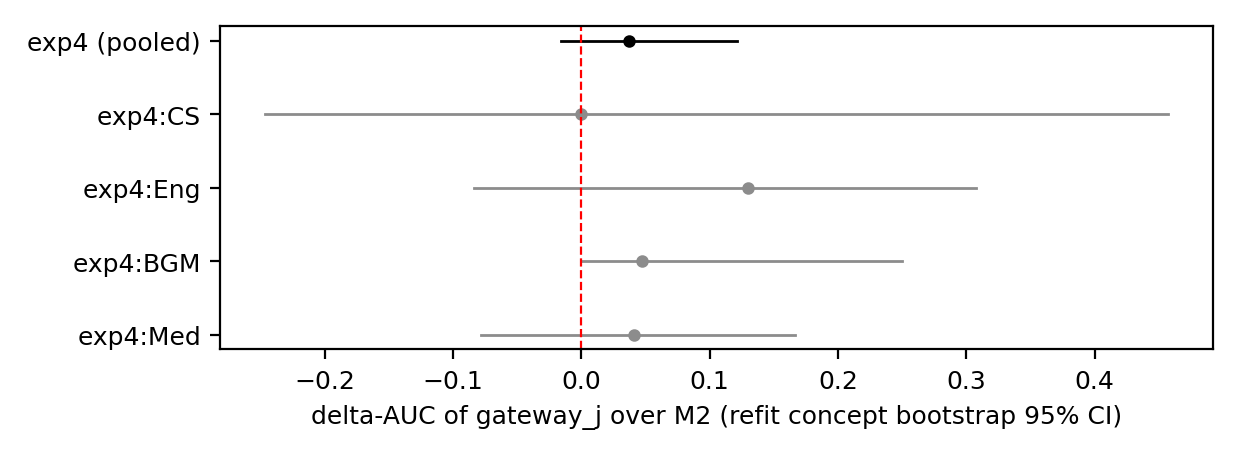

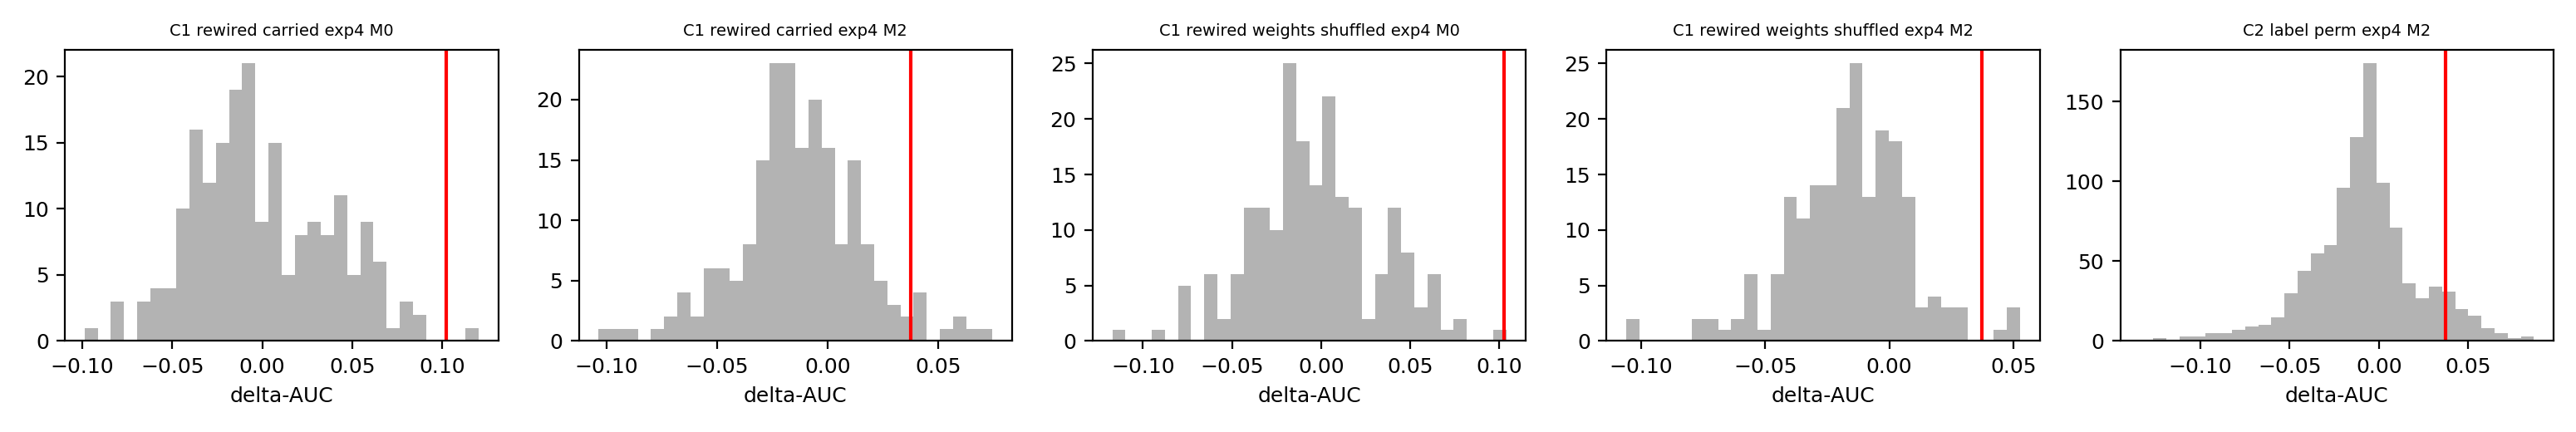

In [27]:
E = {}
figs = figures(A, C, B2, E)
print(figs)
for f in figs:
    display(Image(filename=str(HERE / f), width=620))

## Results: demo run vs. full run, and the pre-registered verdict

The table puts the demo's exp4 numbers (with few bootstrap draws) next to the full run's numbers from
`reference_full_run`. The point estimates are deterministic and should match exactly. The CIs and placebo
percentiles depend on the number of draws and are only indicative at demo scale.

The verdict follows the pre-registered ladder. It uses the **union** panel (362 de-duplicated episodes) and the
**new-episodes-only** panel (282 episodes not in exp4's 80), both from the full run.

**Note on "groups +" for exp4 M2.** The demo counts **3/4** positive groups, and the full run reports 4/4. The difference is floating-point noise. In the full run the CS group's delta is 1.1e-16, which the `> 0` count treats as positive. In this environment it is exactly 0. The other three group deltas are identical: Eng +0.130, BGM +0.048, Med +0.041.

In [28]:
ref = data["reference_full_run"]
ma_ref = ref["metrics_agg_subset"]
cmp_rows = []
for sp_ in ("M0", "M1", "M2", "M2+P", "P_alone", "M2+Ppool", "Ppool_alone"):
    tag = f"exp4_{sp_.replace('+', '_plus_')}"
    s = A["exp4"]["specs"][sp_]
    cmp_rows.append({"exp4 spec": sp_, "demo delta": s["delta"], "full-run delta": ma_ref.get(f"A_{tag}_delta_auc"),
                     "demo CI95": s["refit_boot"].get("ci95"),
                     "full-run CI95": [ma_ref.get(f"A_{tag}_ci95_lo"), ma_ref.get(f"A_{tag}_ci95_hi")]})
cmp = pd.DataFrame(cmp_rows).set_index("exp4 spec")
print("exp4 reproduction (reported 0.10254 / 0.10222):", reproduction["reproduced_from_harmonised_panel"],
      "| exact:", reproduction["exact_to_1e-4"])
print(f"C2 node-label permutation exp4 M2: demo percentile {C['C2_label_perm_exp4_M2']['real_percentile']:.1f} "
      f"(full run {ma_ref.get('C2_label_perm_exp4_M2_real_percentile')})")
display(cmp.round(4))

# Full-run headline (all panels) and verdict
head = pd.DataFrame({ds: {"delta over M2": v["delta"], "CI95 lo": v["ci95"][0], "CI95 hi": v["ci95"][1],
                          "groups +": v["n_groups_positive"]} for ds, v in ref["summary"]["headline"].items()}).T
print("\nFull-run headline: delta-AUC of gateway_j over M2 (refit concept bootstrap, 2000 draws on exp4/union/new_eps)")
display(head.round(4))
print("Pre-registered verdict (full run):", ref["summary"]["verdict"])
for k, v in ref["summary"]["conditions"].items():
    print(f"  {k:40s} {v}")
print("\nFull-run B3 within/between SD ratio:", round(ma_ref.get("B3_sd_ratio_within_between", float("nan")), 4),
      "| validation rho:", round(ma_ref.get("B3_validation_spearman", float("nan")), 3))

# Plot: demo exp4 deltas with refit CIs, next to the full-run headline per panel
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
ax = axs[0]
ys = np.arange(len(tabA))[::-1]
lo = tabA["delta_auc"] - tabA["ci95_lo"]
hi = tabA["ci95_hi"] - tabA["delta_auc"]
ax.errorbar(tabA["delta_auc"], ys, xerr=[lo.fillna(0).clip(lower=0), hi.fillna(0).clip(lower=0)], fmt="o", ms=4, capsize=2)
ax.set_yticks(ys, tabA.index, fontsize=7)
ax.axvline(0, color="r", ls="--", lw=0.8)
ax.set_title(f"exp4 (demo, {A['exp4']['n_boot']} refit draws): delta-AUC per spec")
ax.set_xlabel("delta-AUC")
ax = axs[1]
ys2 = np.arange(len(head))[::-1]
ax.errorbar(head["delta over M2"], ys2, xerr=[head["delta over M2"] - head["CI95 lo"], head["CI95 hi"] - head["delta over M2"]],
            fmt="s", ms=4, capsize=2, color="k")
ax.set_yticks(ys2, head.index)
ax.axvline(0, color="r", ls="--", lw=0.8)
ax.set_title(f"Full run: gateway over M2 per panel -> verdict {ref['summary']['verdict']}")
ax.set_xlabel("delta-AUC (95% refit CI)")
fig.tight_layout()
display(fig)  # figures() switched matplotlib to Agg, so display the figure explicitly
plt.close(fig)

print(f"\nTotal notebook analysis time: {time.time() - t0:.0f}s")
if _EXEC is not None:
    _EXEC.shutdown()

exp4 reproduction (reported 0.10254 / 0.10222): {'gateway_j': 0.10253968253968249, 'size_controlled_gateway_j': 0.10222222222222221} | exact: True
C2 node-label permutation exp4 M2: demo percentile 92.5 (full run 92.5)


,demo delta,full-run delta,demo CI95,full-run CI95
exp4 spec,,,,
M0,0.1025,0.1025,"[0.021229956268221516, 0.20056323582394842]","[0.024652053408572808, 0.19707972582972585]"
M1,0.0740,0.0740,"[-0.001565975733063767, 0.19736742424242407]","[-0.0038261805252323283, 0.18702096734289952]"
M2,0.0375,0.0375,"[-0.01572945857118141, 0.12103363461846085]","[-0.018236774105807162, 0.13]"
M2+P,0.0330,0.0330,"[-0.023045895989974925, 0.08550724637681159]","[-0.01886829565191584, 0.08543507146448315]"
P_alone,-0.0305,-0.0305,"[-0.14637505645889784, 0.10812467650103506]","[-0.15000364431486882, 0.10637035138240468]"
M2+Ppool,0.0419,0.0419,"[-0.014388670744292533, 0.12851274230905654]","[-0.01686306063122931, 0.11830894510582016]"
Ppool_alone,-0.0610,-0.0610,"[-0.13970610119047613, 0.02005298353909462]","[-0.1365505805683283, 0.015147965743099385]"



Full-run headline: delta-AUC of gateway_j over M2 (refit concept bootstrap, 2000 draws on exp4/union/new_eps)


,delta over M2,CI95 lo,CI95 hi,groups +
exp4,0.0375,-0.0182,0.1300,4.0
exp1,0.0006,-0.0210,0.0095,2.0
exp1_clean,-0.0054,-0.0319,0.0206,1.0
exp3,-0.0057,-0.0516,0.0700,1.0
union,0.0009,-0.0121,0.0120,1.0
new_eps,-0.0006,-0.0211,0.0174,3.0
union_agree,0.0002,-0.0192,0.0083,1.0


Pre-registered verdict (full run): FAILS
  new_eps_delta_gt_0                       False
  union_delta_gt_0_ci95_gt_0               False
  new_eps_delta_gt_0_ci95_gt_0             False
  union_ge3of4_groups_positive             False
  survives_P_within_union_ci95_gt_0        False
  above_C2_p95_union                       False
  P_alone_carries_gain_union               False
  gateway_adds_le_0.01_given_P_union       True
  inside_C2_null_union                     True

Full-run B3 within/between SD ratio: 0.0232 | validation rho: 0.917


<Figure size 1200x400 with 2 Axes>


Total notebook analysis time: 269s
